In [1]:
import numpy as np
import xarray as xr
import json

import matplotlib.pyplot as plt

from feature_retreiver import *

In [2]:
def calculate_f(latitude: float):
    omega = 2 * np.pi / 24 / 60 / 60
    return 2 * omega * np.sin(latitude * np.pi / 180)

In [3]:
def calculate_T(latitude: float):
    return 2 * np.pi / calculate_f(latitude)

In [4]:
def calculate_mean_over_inertial_period(
        data: np.ndarray,
        latitudes: np.ndarray,
        dt: float = 50
) -> np.ndarray:
    m, _ = data.shape
    ten_days = 10 * 24 * 60 * 60  # HARD CODED BABEY; this is the issue with the long runs; should be accounted for
    averages, variances = np.empty(m), np.empty(m)
    for i in range(m):
        if latitudes[i] <= 5:
            averages[i], variances[i] = np.nanmean(data[i]), np.nanstd(data[i])
        else:
            inertial_period = calculate_T(latitude=latitudes[i])
            n_steps_per_period = int(inertial_period / dt)
            array = data[i, n_steps_per_period:]  # discard the first inertial period
            n_chunks = int(ten_days / inertial_period) - 1
            average, variance = np.empty(n_chunks + 1), np.empty(n_chunks + 1)
            for j in range(n_chunks):
                start, end = n_steps_per_period*j, n_steps_per_period*(j+1)
                average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2
            average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2
            averages[i], variances[i] = np.nanmean(average), np.nanmean(variance)
    return averages, variances

In [5]:
def calculate_analytical_m_star_N(x, c_N1, c_N2, c_N3):
    return c_N1 * (1 - (1 + c_N2 * np.exp(-c_N3*x)) ** -1)

In [6]:
def calculate_analytical_m_star_Nb(x, c_Nb1, c_Nb2):
    return c_Nb1 * np.exp(-c_Nb2 * x)

In [7]:
def last_profile(
        output: xr.Dataset,
        variable: str
) -> np.ndarray:
    return output[variable].isel(time=-1).values

## DATASET NAME AND ROOTDIR

In [8]:
training_set_name = "ePBL_paper_linear"
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

## CASE COMPARISON

In [43]:
training_set_name_1 = "ePBL_paper_linear"
training_set_name_2 = "ePBL_paper"

In [45]:
with open(f"{root_dir}/{training_set_name_1}_training_set_cases.json", "r") as file:
    gotm_case_dict_1 = json.load(file)

with open(f"{root_dir}/{training_set_name_2}_training_set_cases.json", "r") as file:
    gotm_case_dict_2 = json.load(file)

In [94]:
target_specs = {'temp_grad': 0.001, 'tx': 1.0, 'lat': 10.0, 'heat_flux': 0}

for case, specs in gotm_case_dict_1.items():
    if specs == target_specs:
        case_1 = case 
    else: pass

for case, specs in gotm_case_dict_2.items():
    if specs == target_specs:
        case_2 = case
    else: pass

In [95]:
print(case_1, case_2)

case_111 case_401


In [96]:
ds_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_training_dataset/{case_1}/output.nc").isel(lat=0, lon=0)
ds_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_training_dataset/{case_2}/output.nc").isel(lat=0, lon=0)

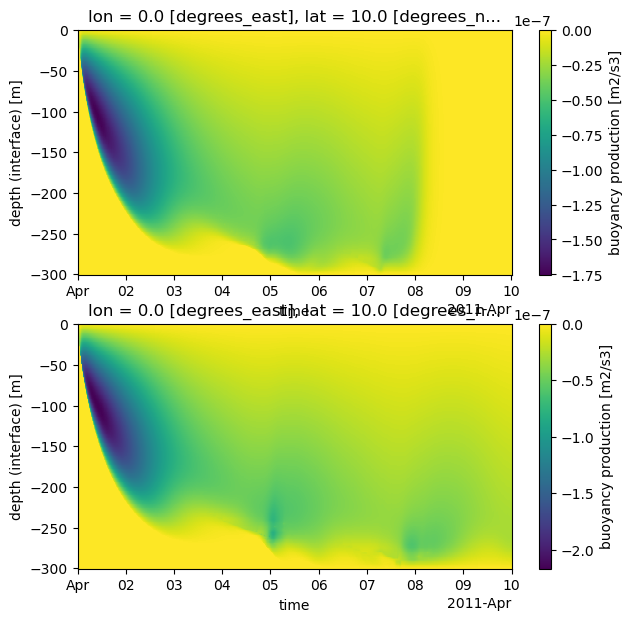

In [97]:
fig, ax = plt.subplots(2,1,figsize=(7,7))

ds_1.G.T.plot(ax=ax[0])
ds_2.G.T.plot(ax=ax[1])

In [98]:
m_star_dataset_1 = xr.open_dataset(f"{root_dir}/{training_set_name_1}_m_star_G.nc")
m_star_dataset_2 = xr.open_dataset(f"{root_dir}/{training_set_name_2}_m_star_G.nc")

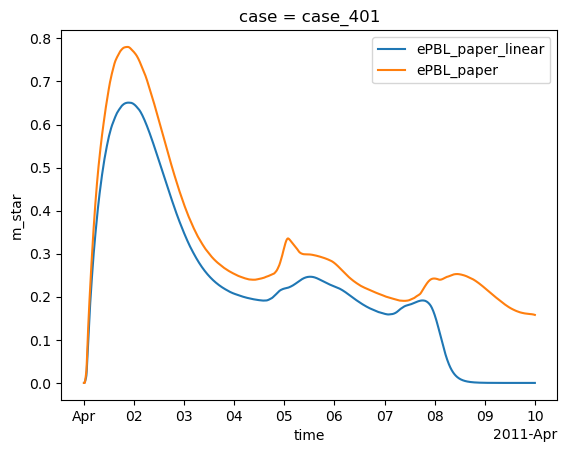

In [99]:
m_star_dataset_1.sel(case=case_1).m_star.plot(label=training_set_name_1)
m_star_dataset_2.sel(case=case_2).m_star.plot(label=training_set_name_2)
plt.legend()

## TEST FEATURE RETREIVER

In [4]:
test_ds = xr.open_dataset(f"{root_dir}/{training_set_name}_training_dataset/case_28/output.nc").isel(lat=0, lon=0)

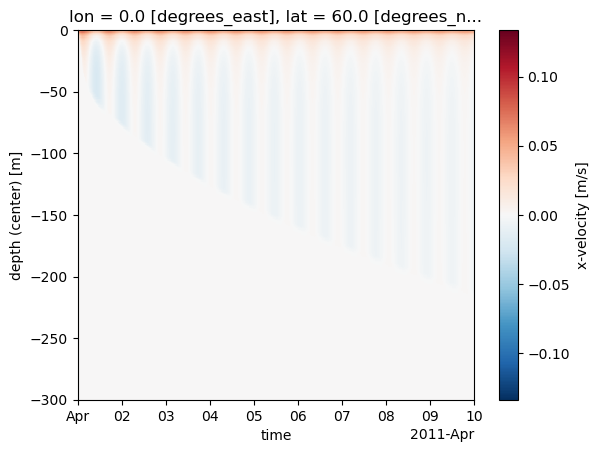

In [5]:
test_ds.u.T.plot()

In [4]:
# test_ds = xr.open_dataset(f"{root_dir}/{training_set_name}_training_dataset/case_22/output.nc").isel(lat=0, lon=0)
# test_ds_weird = xr.open_dataset(f"{root_dir}/{training_set_name}_training_dataset/case_73/output.nc").isel(lat=0, lon=0)

In [5]:
# plt.figure()
# test_ds['nuh'].T.plot(vmax=0.15)
# plt.figure()
# test_ds_weird['nuh'].T.plot(vmax=0.15)

In [6]:
# plt.figure()
# test_ds['temp_p'].pad(z=(1), mode="edge").diff(dim='z').T.plot(vmax=0.5)
# plt.figure()
# test_ds_weird['temp_p'].pad(z=(1), mode="edge").diff(dim='z').T.plot(vmax=0.5)

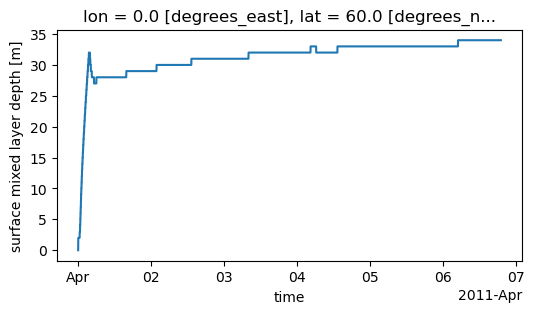

In [7]:
test_ds.mld_surf.isel(time=slice(0,10000)).T.plot(figsize=(6,3))
# plt.savefig('inertial_oscillations.png', dpi=300)

In [8]:
gotm_case_dict = {
    "case_1": {
        "temp_grad": 0.04,
        "tx": 0.1,
        "lat": 10.0,
        "heat_flux": -100
    },
    "case_2": {
        "temp_grad": 0.04,
        "tx": 0.1,
        "lat": 10.0,
        "heat_flux": -75
    },
    "case_3": {
        "temp_grad": 0.04,
        "tx": 0.1,
        "lat": 10.0,
        "heat_flux": -50
    }
}

In [4]:
feature_retreiver = FeatureRetreiver(
    training_set_dir=os.path.join(root_dir, f"{training_set_name}_training_dataset"),
    case_dict=gotm_case_dict
)

NameError: name 'gotm_case_dict' is not defined

In [10]:
test = feature_retreiver.make_m_star_dataset()

In [11]:
test_2 = feature_retreiver.make_dataset_from_raw_data(
    variable="mld_surf",
    coordinates=["time"]
)

In [ ]:
test_3 = feature_retreiver.make_dataset_from_processed_data(
    processing_method=last_profile,
    processing_method_name="last_temp_profile",
    variable="temp",
    coordinates=["z"]
)

In [13]:
test_3

<xarray.Dataset> Size: 8kB
Dimensions:                 (z: 300, case: 3)
Coordinates:
  * z                       (z) float32 1kB -299.5 -298.5 -297.5 ... -1.5 -0.5
  * case                    (case) <U6 72B 'case_1' 'case_2' 'case_3'
Data variables:
    last_temp_profile_temp  (case, z) float64 7kB 19.47 19.5 ... 30.38 30.38

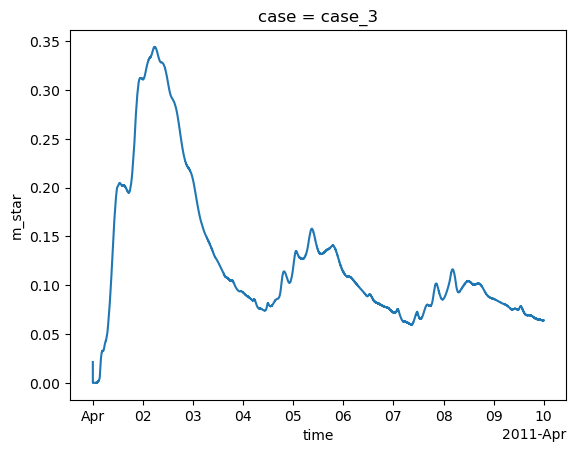

In [14]:
test.m_star[2,:].plot()

In [9]:
with open(f"{root_dir}/{training_set_name}_training_set_cases.json", "r") as file:
    gotm_case_dict = json.load(file)

In [10]:
feature_retreiver = FeatureRetreiver(
    training_set_dir=os.path.join(root_dir, f"{training_set_name}_training_dataset"),
    case_dict=gotm_case_dict
)

In [11]:
for case, specs in gotm_case_dict.items():
    if specs == {'lat': 10., 'tx': 0.1, 'heat_flux': 0., 'temp_grad': 0.001}:
        print(case) 
    else: pass

case_7


In [12]:
latitudes = np.array([case['lat'] for case in gotm_case_dict.values()])
wind_stresses = np.array([case['tx'] for case in gotm_case_dict.values()])
heat_fluxes = np.array([case['heat_flux'] for case in gotm_case_dict.values()])
temp_grads = np.array([case['temp_grad'] for case in gotm_case_dict.values()])

In [13]:
cases = np.arange(1,len(latitudes)+1)

In [11]:
# this takes waaaay too long; need to optimize
# Actually, Qing says that gaea is simply very slow at analysis; we have to move it to PPAN
m_star_dataset = feature_retreiver.make_m_star_dataset()
m_star_dataset.to_netcdf(f"{root_dir}/{training_set_name}_m_star_G.nc")

KeyboardInterrupt: 

In [ ]:
mld_dataset = feature_retreiver.make_dataset_from_raw_data(
    variable="mld_surf",
    coordinates=["time"]
)

mld_dataset.to_netcdf(f"{root_dir}/{training_set_name}_mld.nc")

In [ ]:
bl_dataset = feature_retreiver.make_bl_dataset()

bl_dataset.to_netcdf(f"{root_dir}/{training_set_name}_bl.nc")

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:64: RuntimeWarning

In [14]:
m_star_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_m_star_G.nc")
mld_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_mld.nc")

In [26]:
bl_dataset = xr.open_dataset(f"{root_dir}/{training_set_name}_bl.nc")

In [16]:
calculate_T(5) / 60 / 60 / 24

np.float64(5.736856622834928)

In [137]:
last_m_star = m_star_dataset.m_star.values[:,-1]
last_bl = bl_dataset.bl.values[:,-1]

In [18]:
# m_stars = calculate_mean_over_inertial_period(
#     data=m_star_dataset.m_star.values[heat_fluxes >= 0],
#     latitudes=latitudes[heat_fluxes >= 0]
# )

m_stars, m_star_variances = calculate_mean_over_inertial_period(
    data=m_star_dataset.m_star.values,
    latitudes=latitudes,
    dt=600
)

/tmp/ipykernel_1876963/3495655317.py:20: RuntimeWarning: Mean of empty slice
  average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2
/tmp/ipykernel_1876963/3495655317.py:21: RuntimeWarning: Mean of empty slice
  average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2


In [17]:
# mlds = calculate_mean_over_inertial_period(
#     data=mld_dataset.mld_surf.values[heat_fluxes >= 0],
#     latitudes=latitudes[heat_fluxes >= 0]
# )

mlds, mld_variances = calculate_mean_over_inertial_period(
    data=mld_dataset.mld_surf.values,
    latitudes=latitudes,
    dt=600
)

/tmp/ipykernel_1876963/3495655317.py:20: RuntimeWarning: Mean of empty slice
  average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/miniconda/envs/scientific_python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1876963/3495655317.py:21: RuntimeWarning: Mean of empty slice
  average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2


In [27]:
bls, bl_variances = calculate_mean_over_inertial_period(
    data=bl_dataset.bl.values,
    latitudes=latitudes,
    dt=600
)

/tmp/ipykernel_1876963/3495655317.py:20: RuntimeWarning: Mean of empty slice
  average[j], variance[j] = np.nanmean(array[start:end]), np.nanstd(array[start:end]) ** 2
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/miniconda/envs/scientific_python/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1876963/3495655317.py:21: RuntimeWarning: Mean of empty slice
  average[n_chunks], variance[n_chunks] = np.nanmean(array[end:]), np.nanstd(array[end:]) ** 2


In [19]:
data_list = [m_stars, mlds, wind_stresses, heat_fluxes, temp_grads, latitudes]
data_namelist = ["m_star", "mld", "tau", "hf", "t_grad", "lat"]

In [23]:
var, var_name = mlds, 'mld'
case_names = [case_name for case_name in gotm_case_dict.keys()]
coords = {'case': case_names}
data_vars = {f"mean_{var_name}": xr.DataArray(
    var,
    dims=['case'],
    coords=coords
    )}
ds = xr.Dataset(
    data_vars=data_vars,
    coords=coords
    )

save = False

if save:
    ds.to_netcdf(f"{root_dir}/{training_set_name}_mean_{var_name}.nc")

In [24]:
gotm_case_dict['case_30']

{'temp_grad': 0.001, 'tx': 0.1, 'lat': 60.0, 'heat_flux': -75}

/tmp/ipykernel_1876963/566308894.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


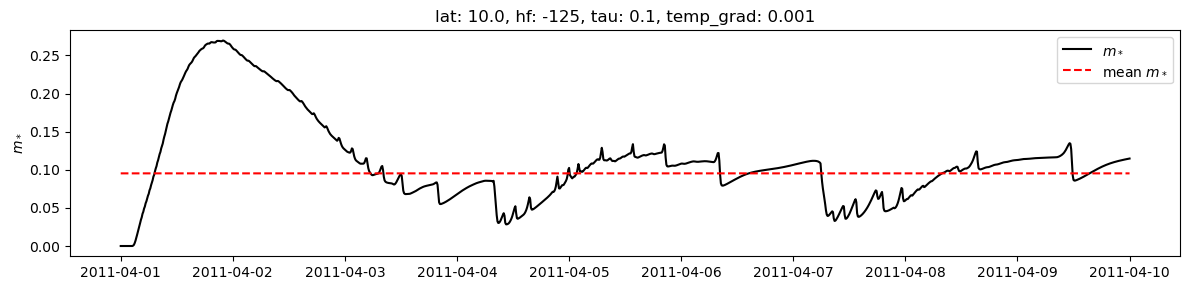

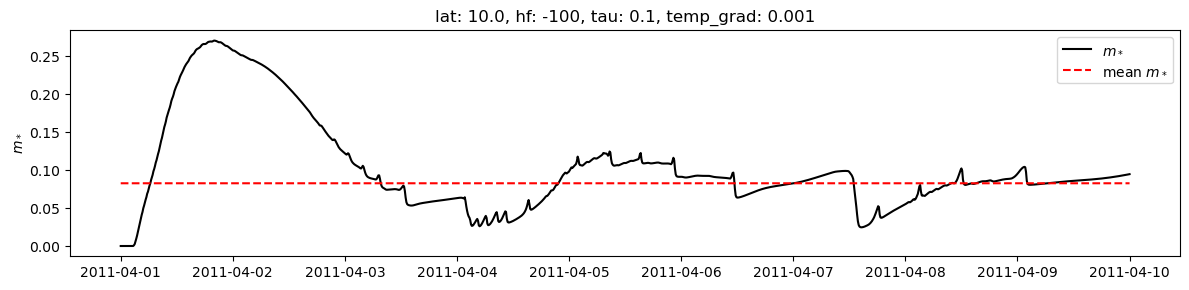

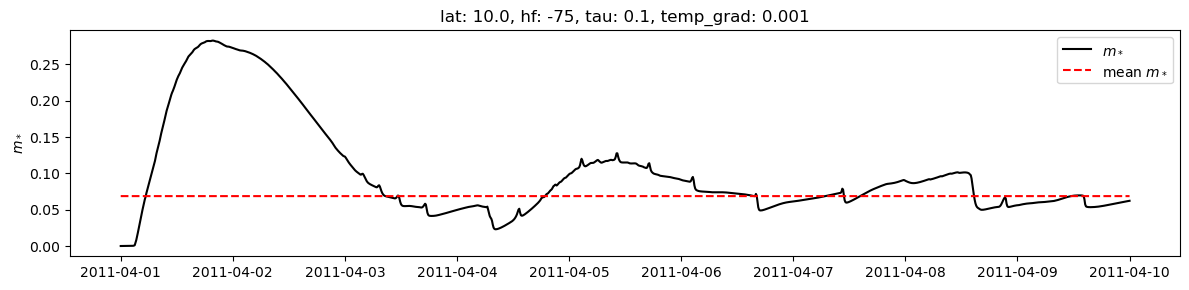

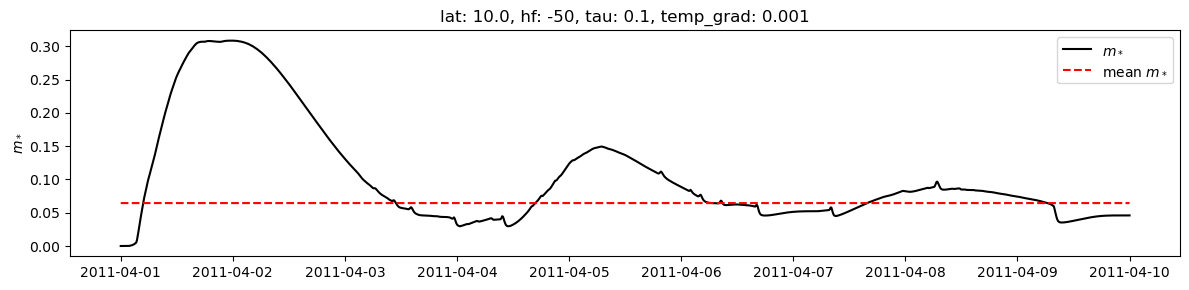

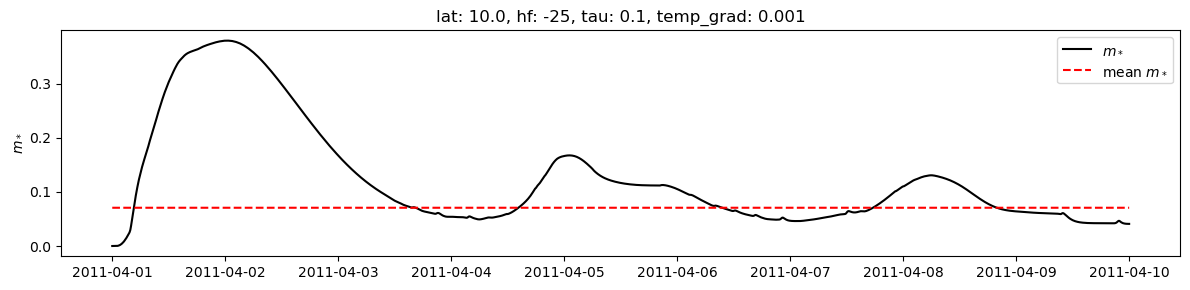

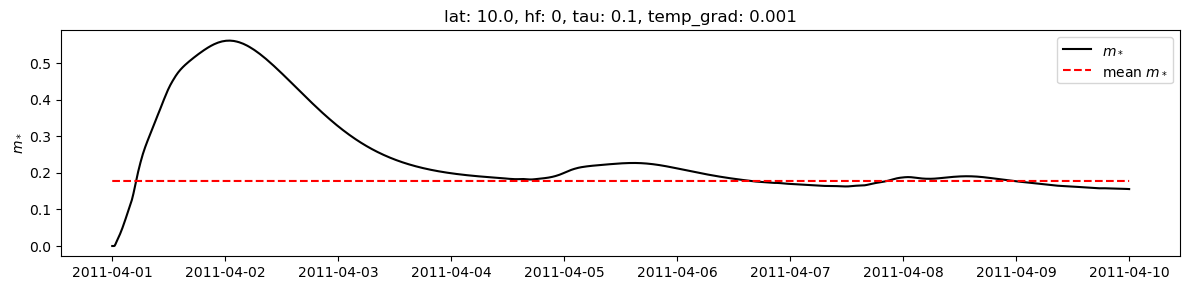

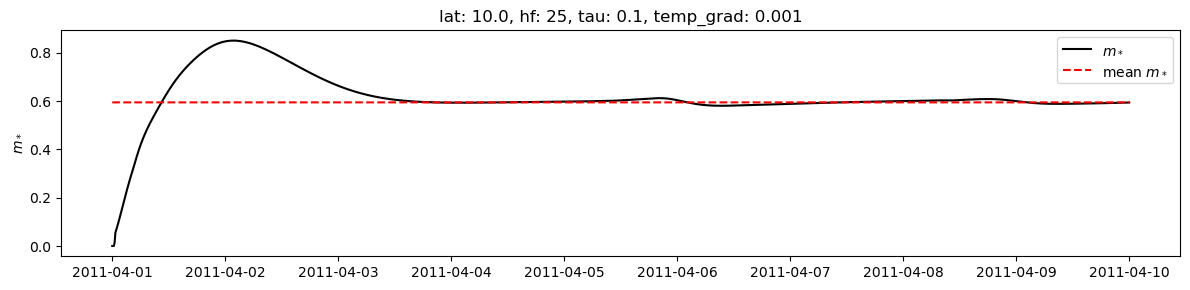

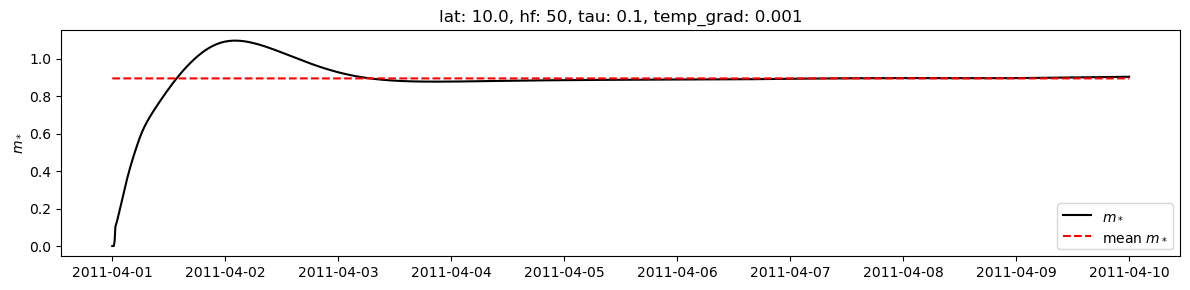

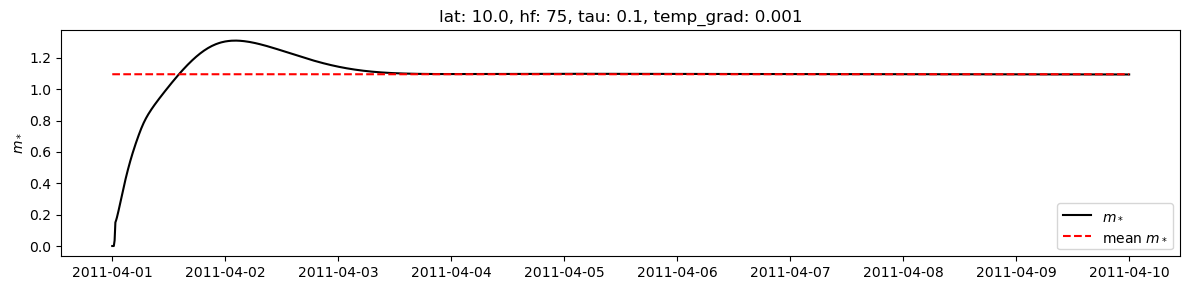

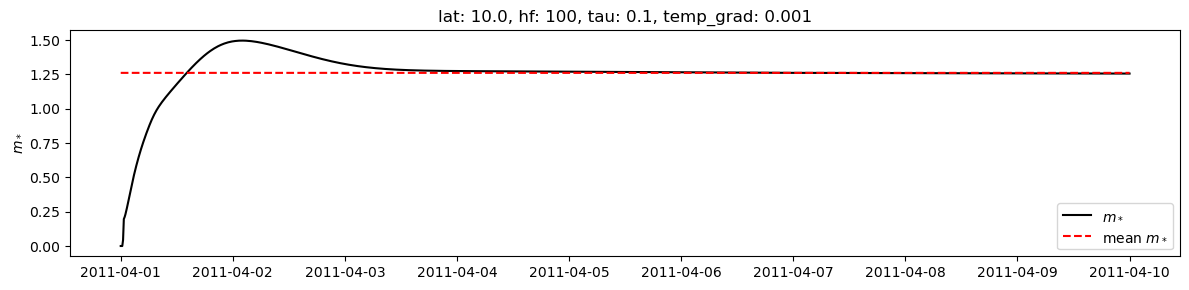

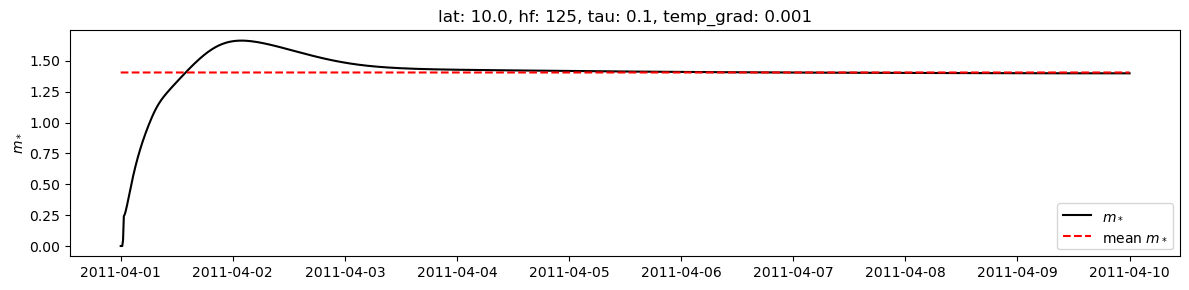

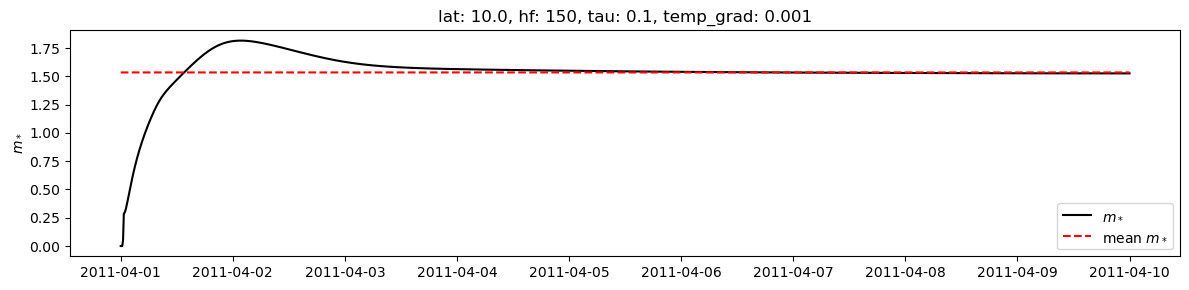

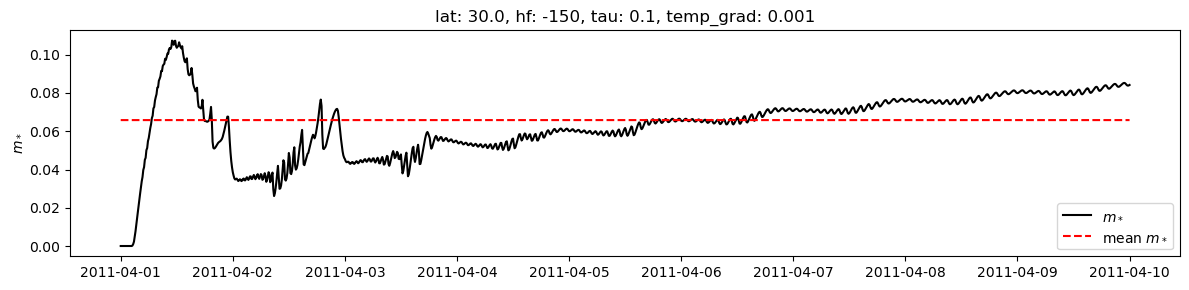

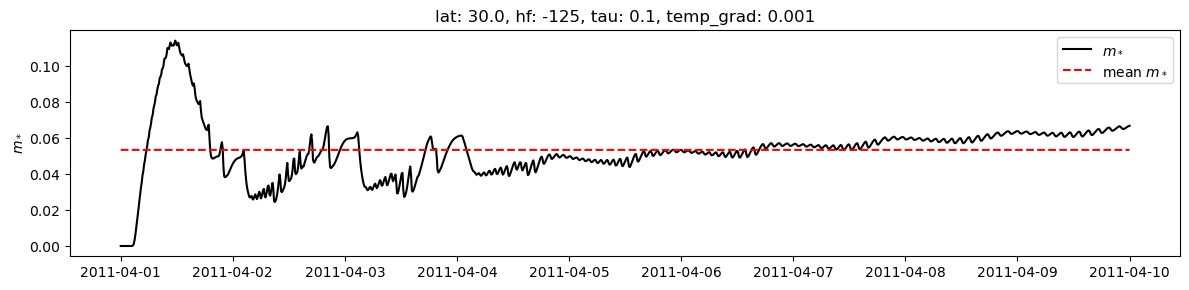

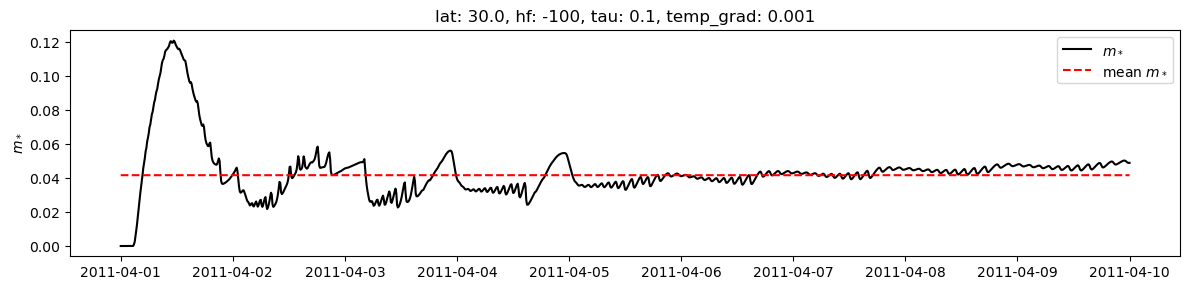

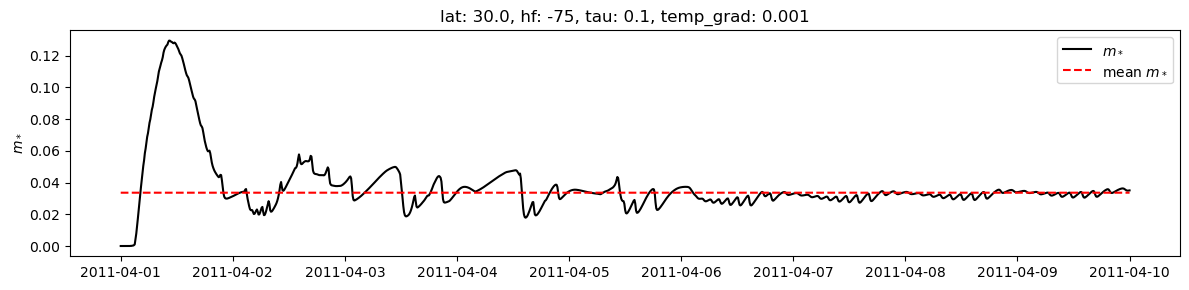

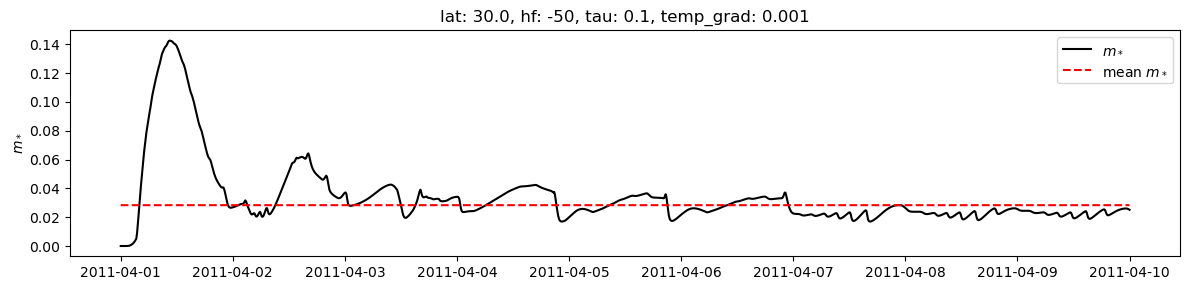

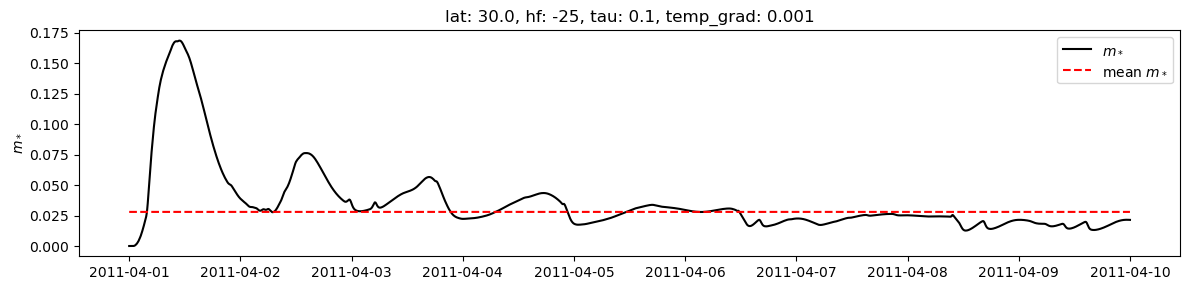

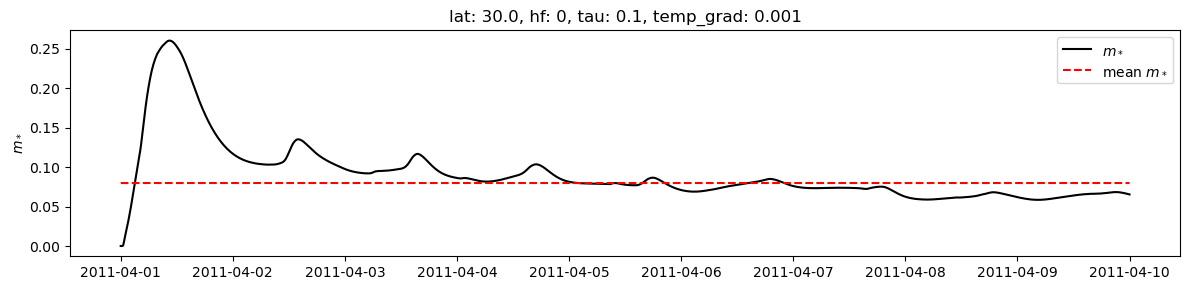

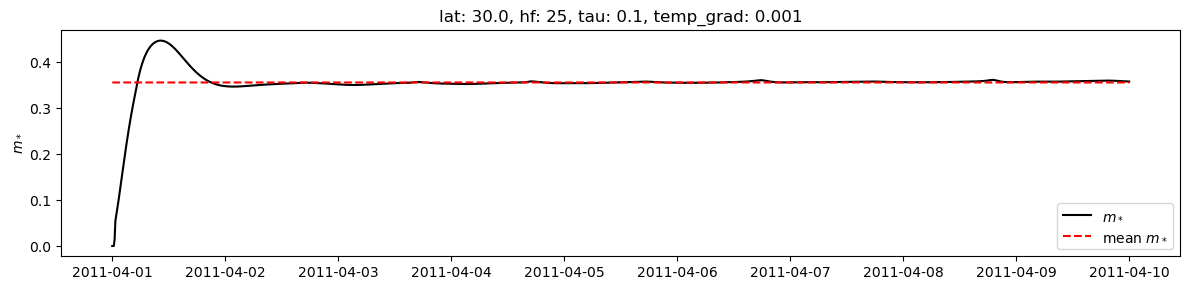

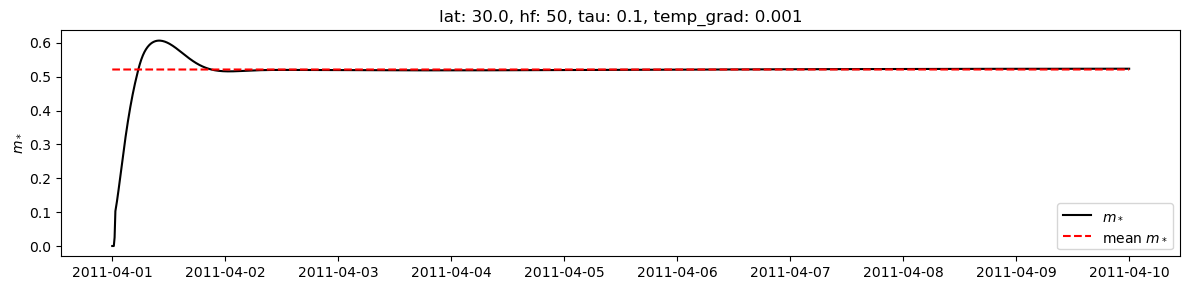

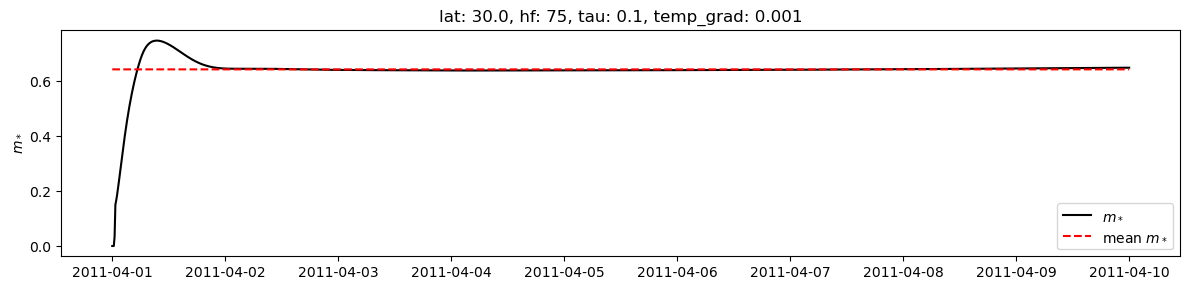

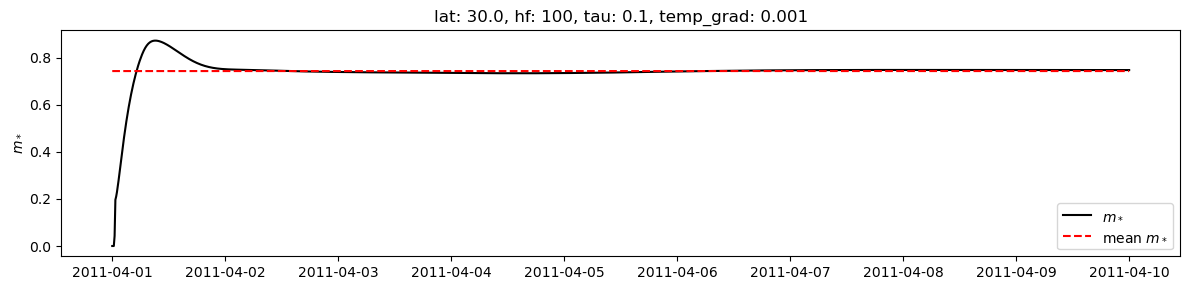

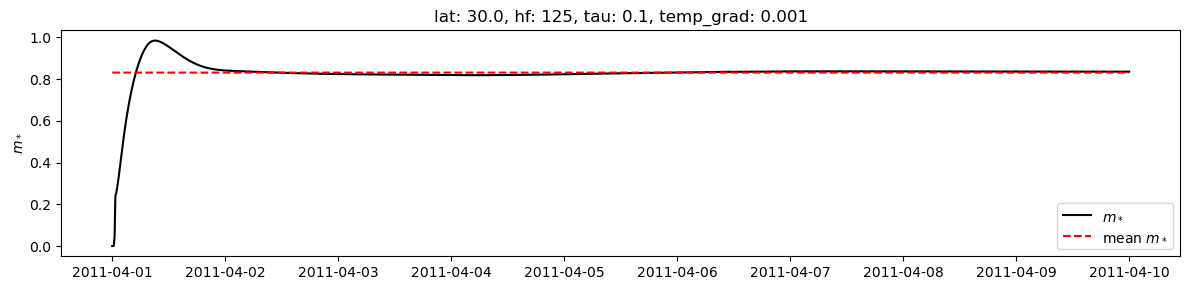

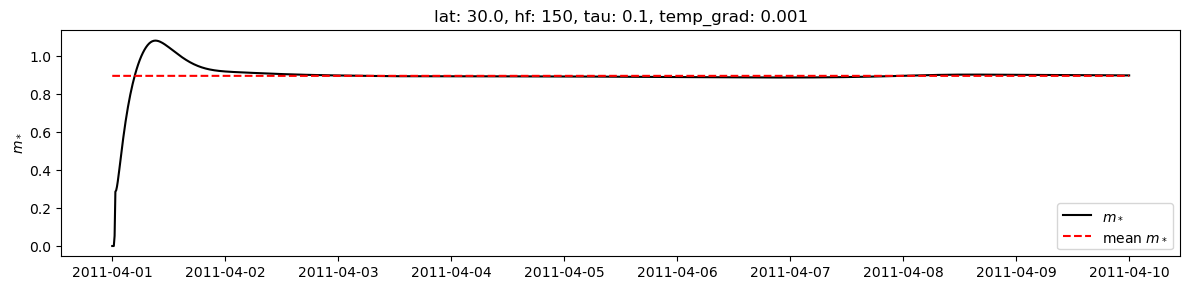

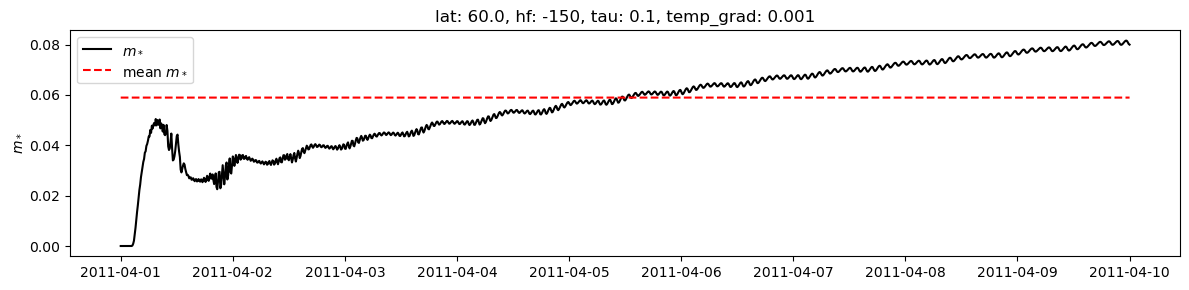

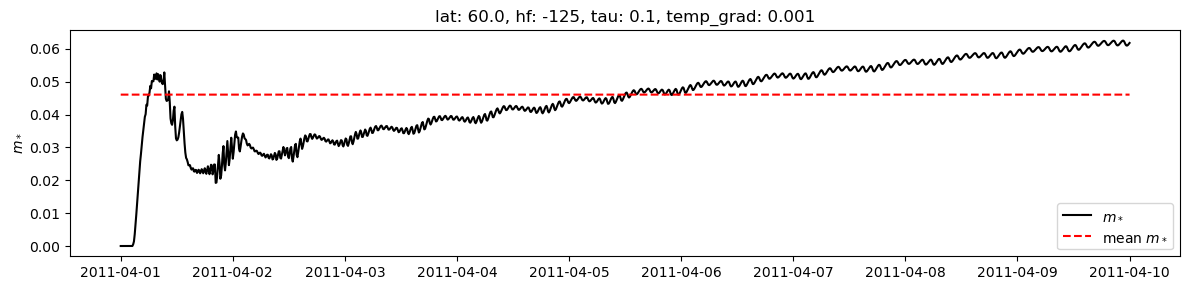

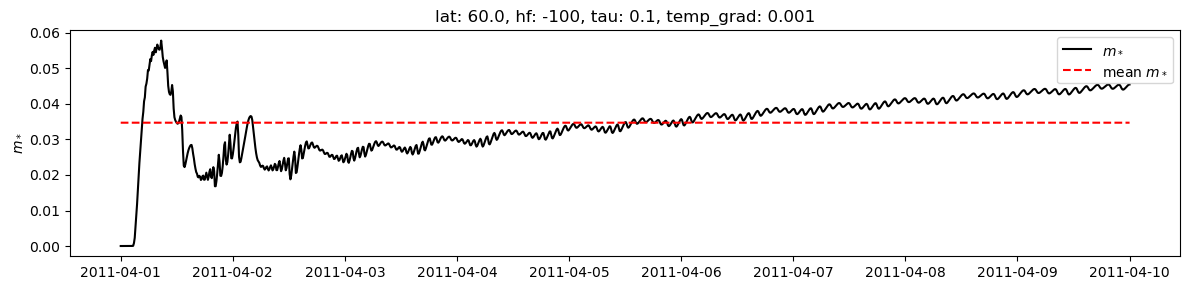

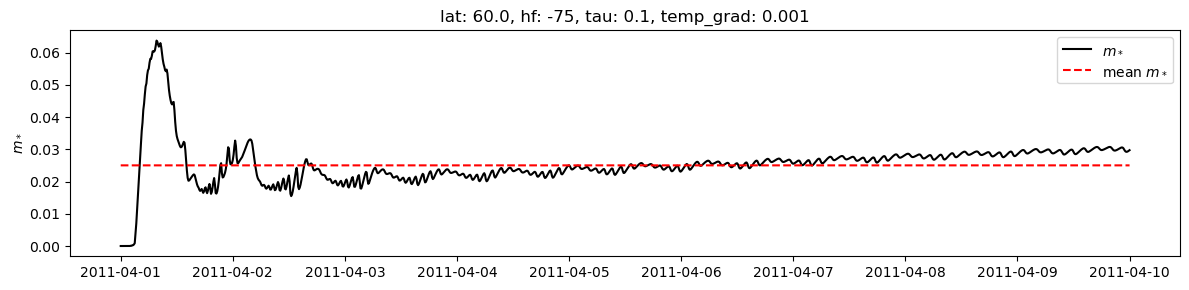

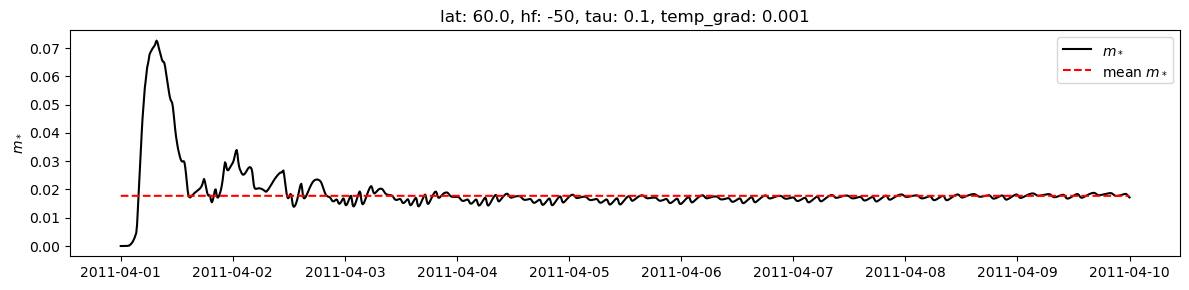

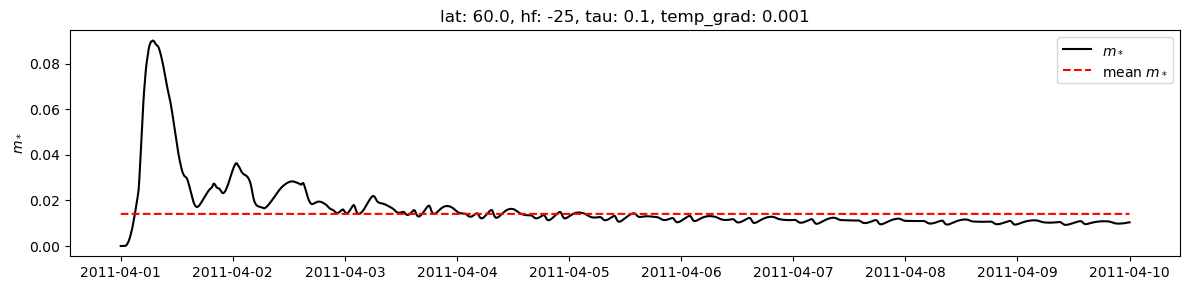

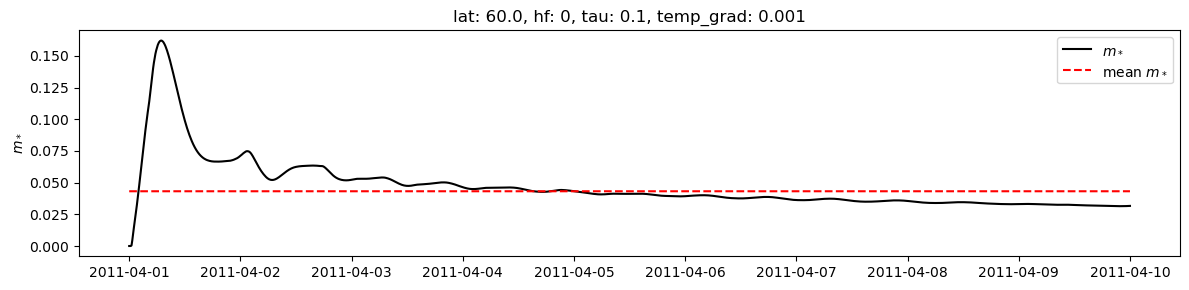

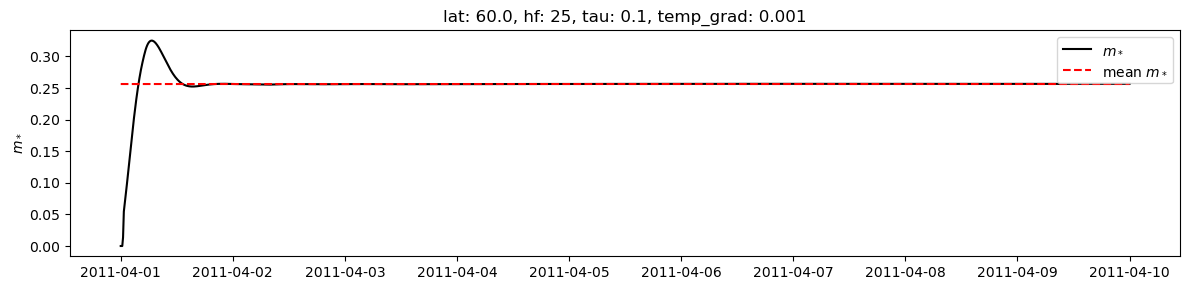

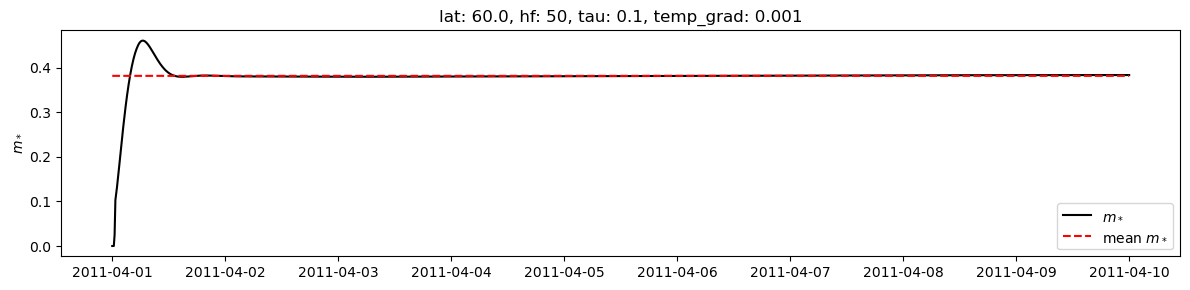

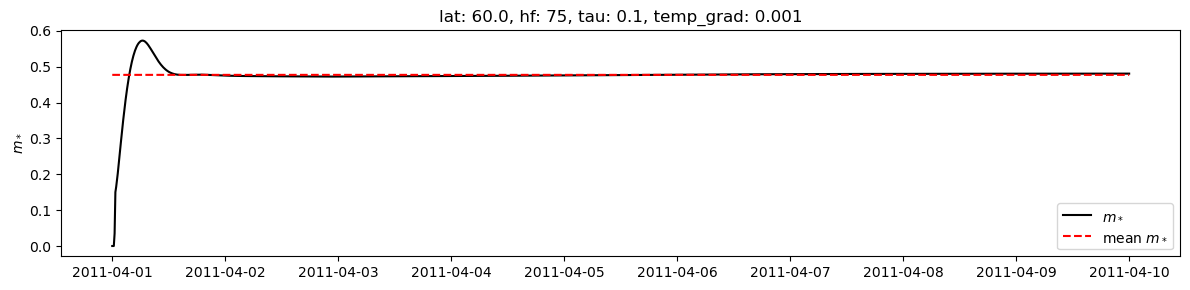

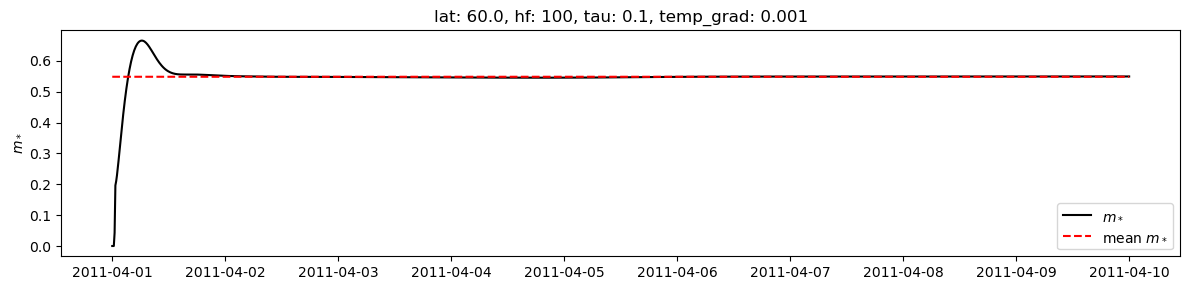

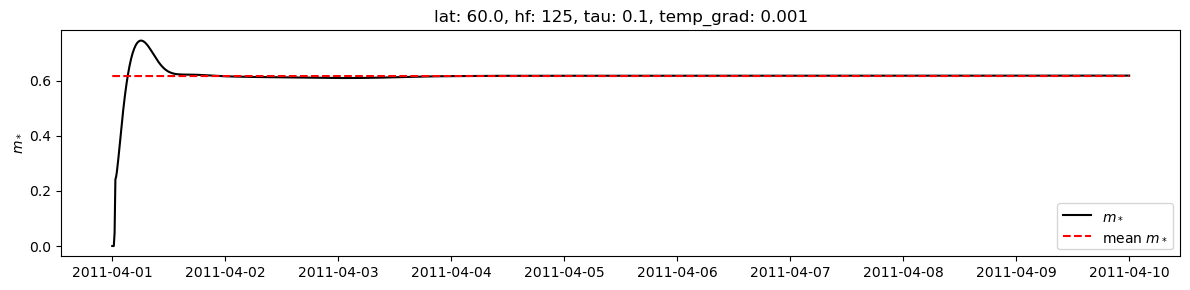

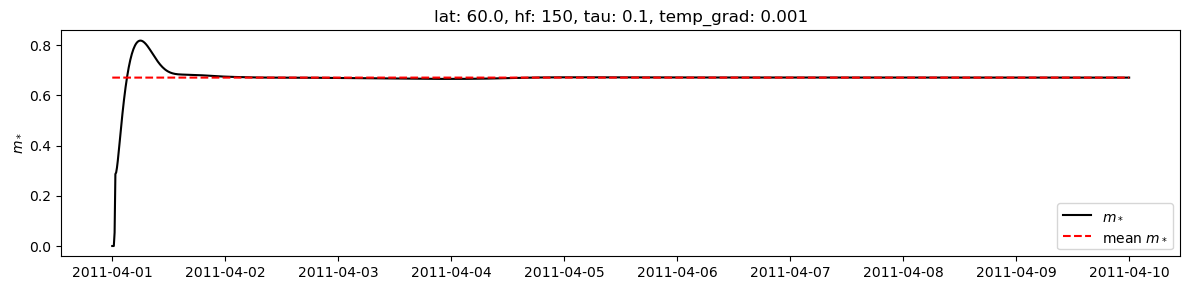

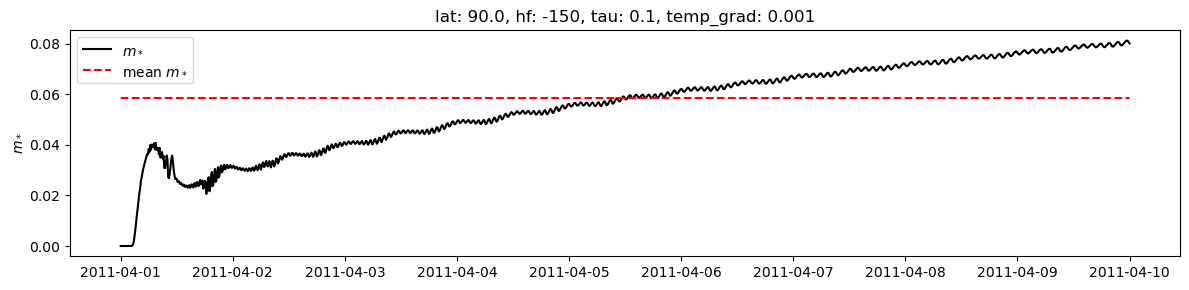

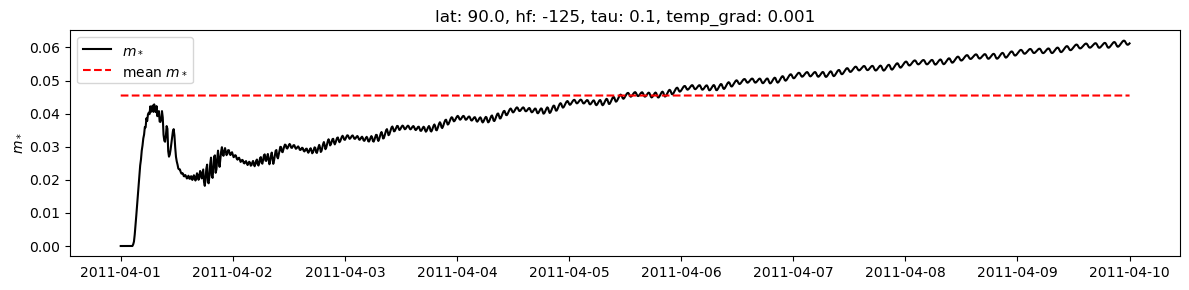

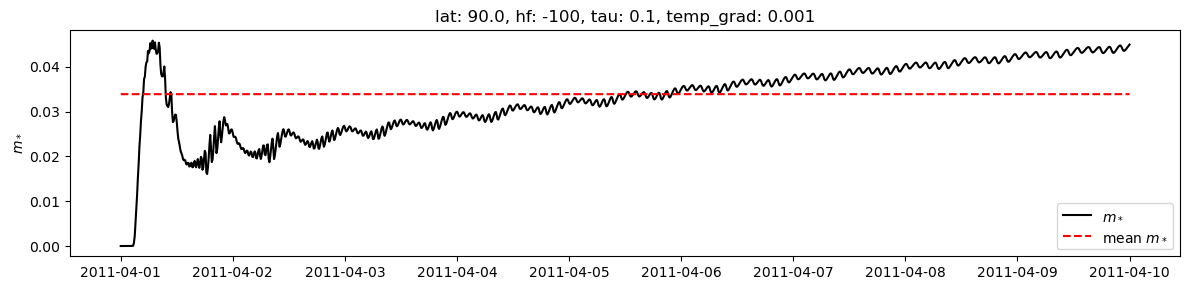

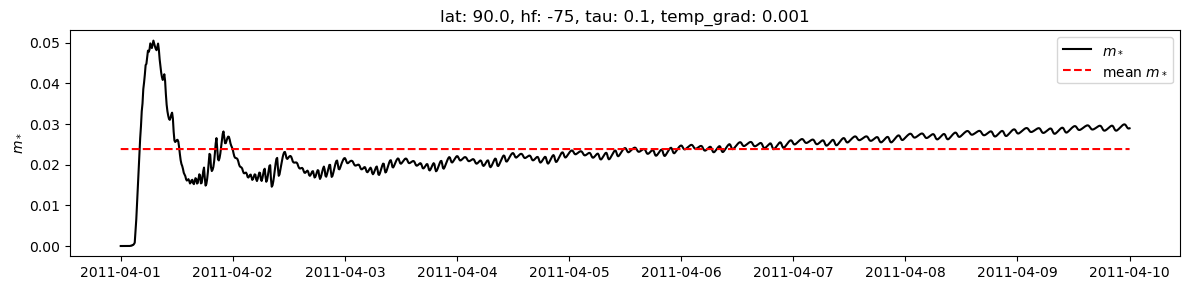

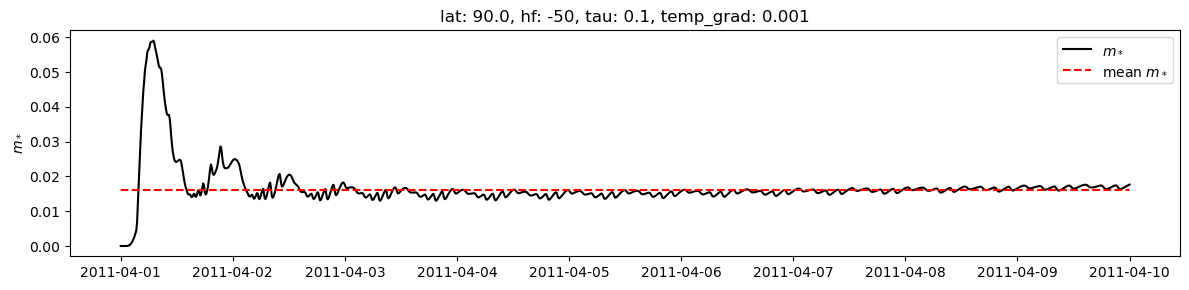

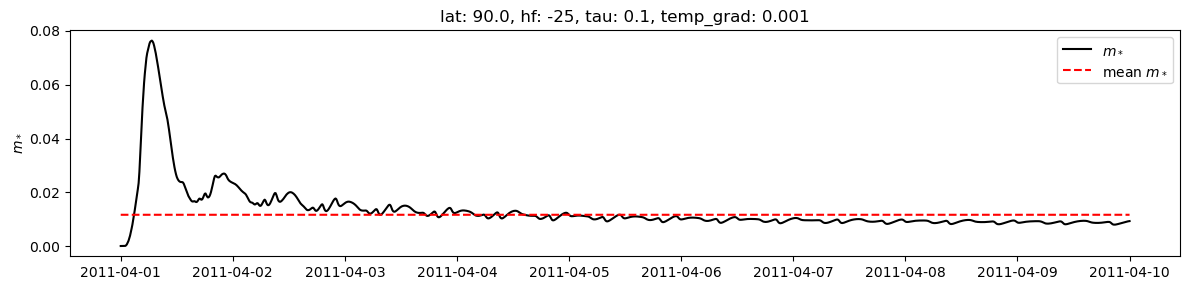

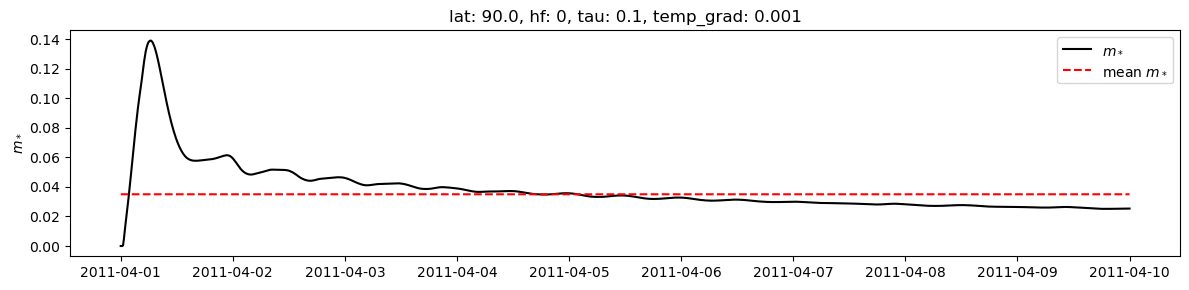

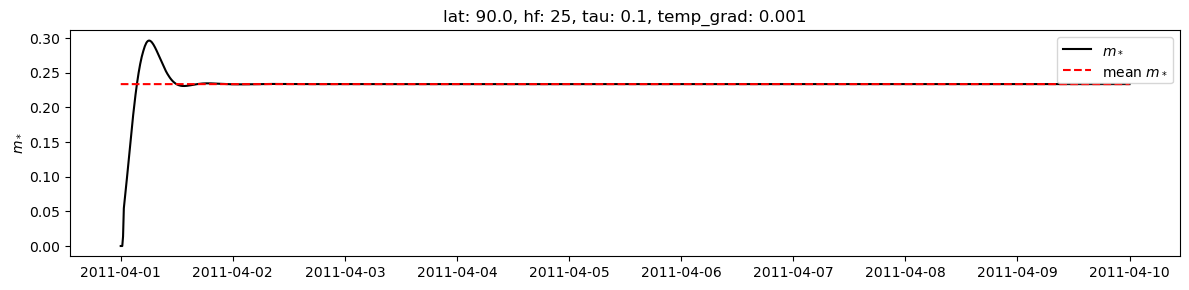

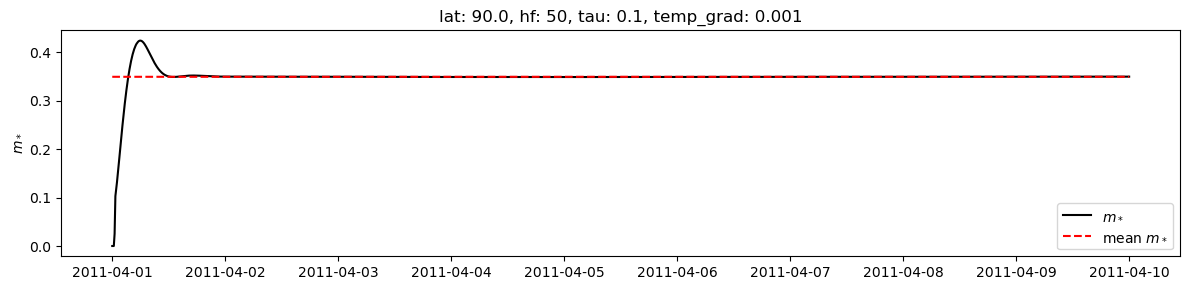

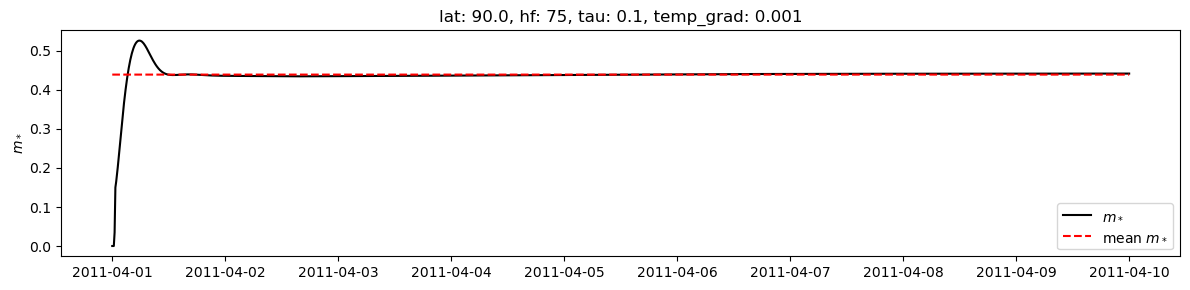

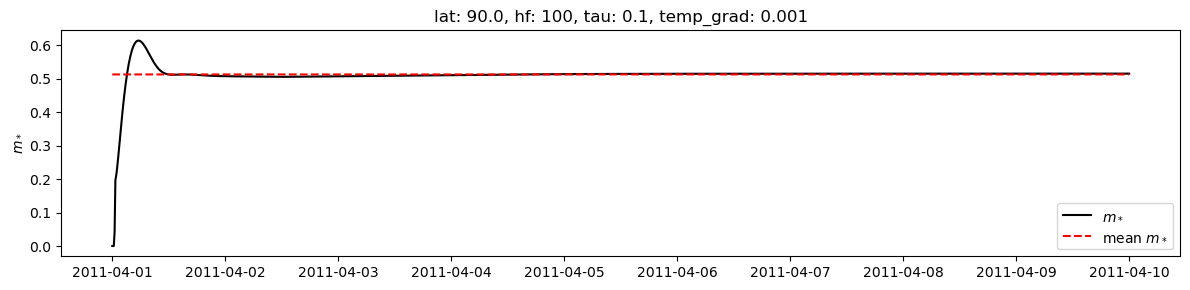

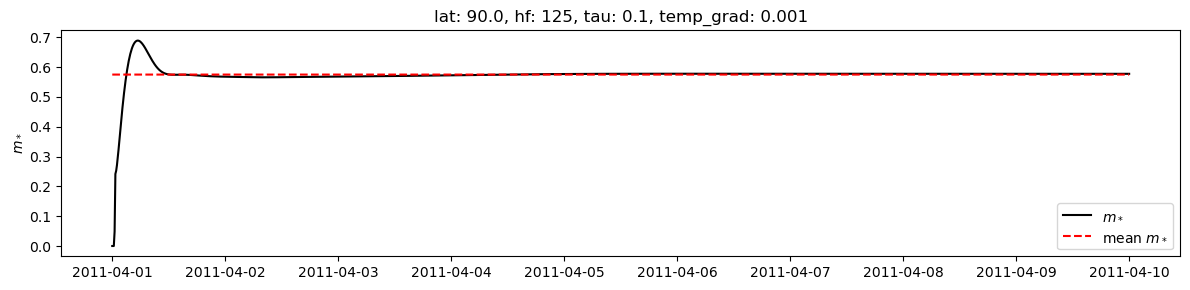

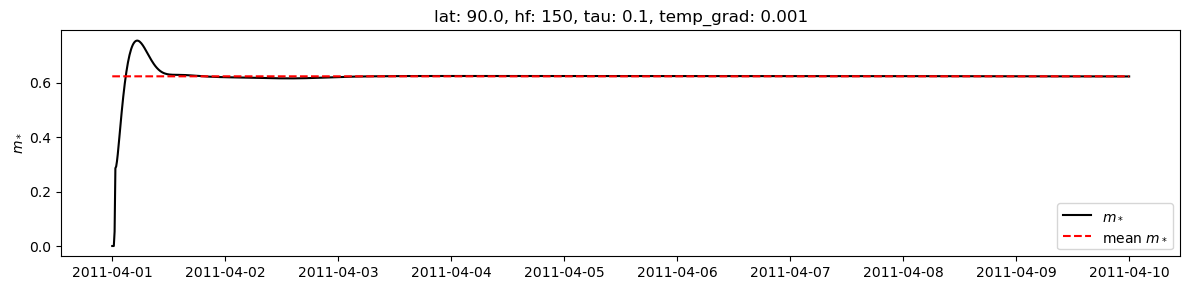

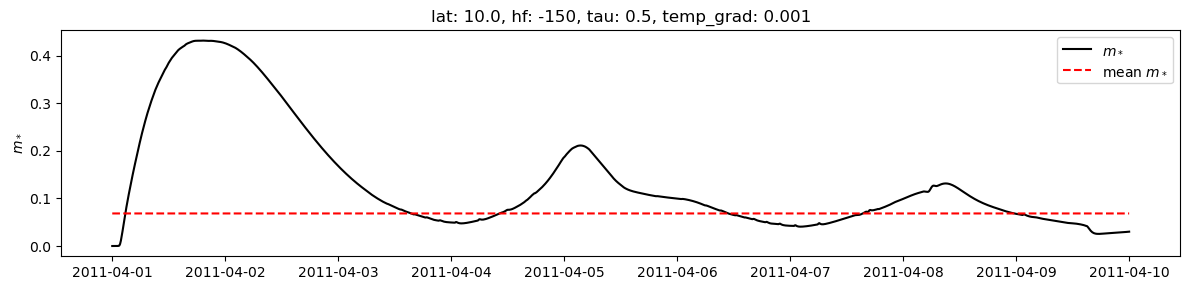

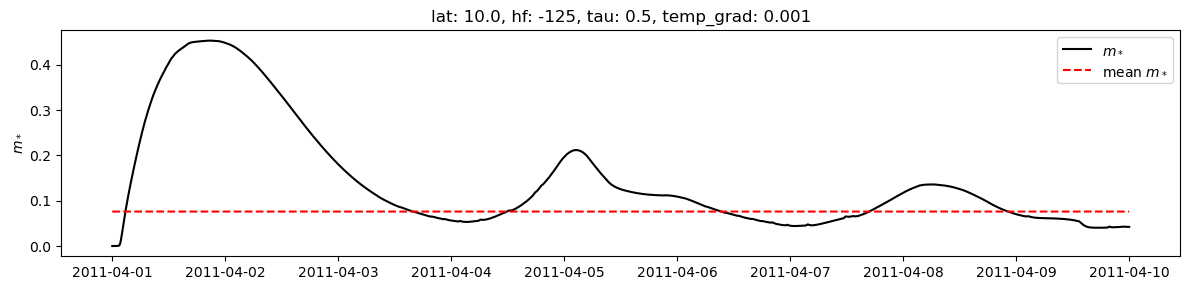

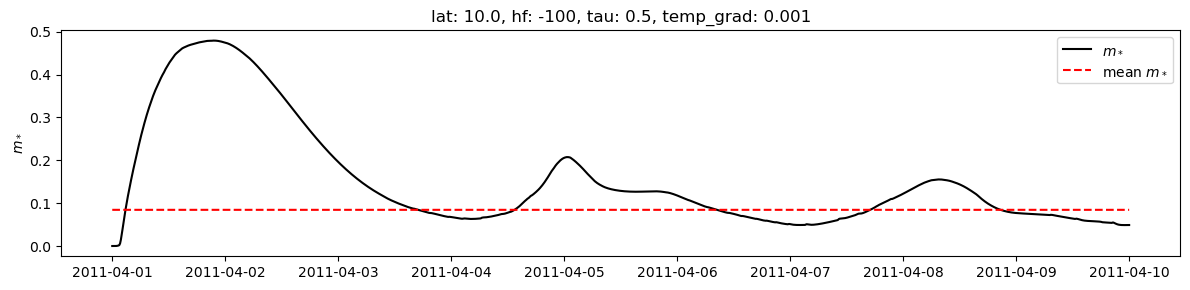

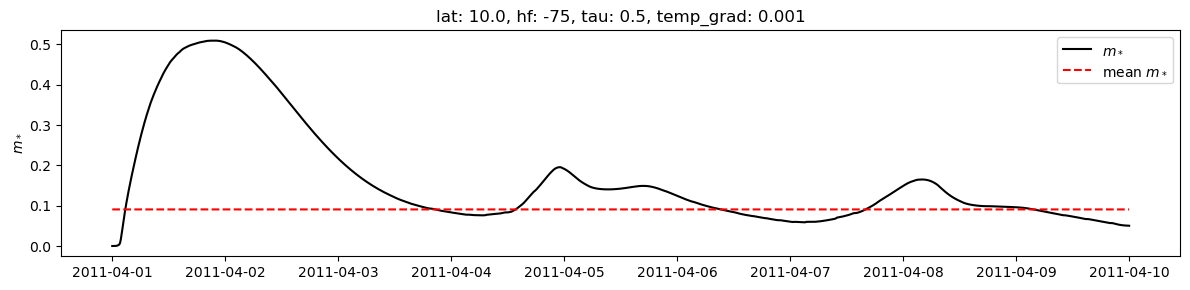

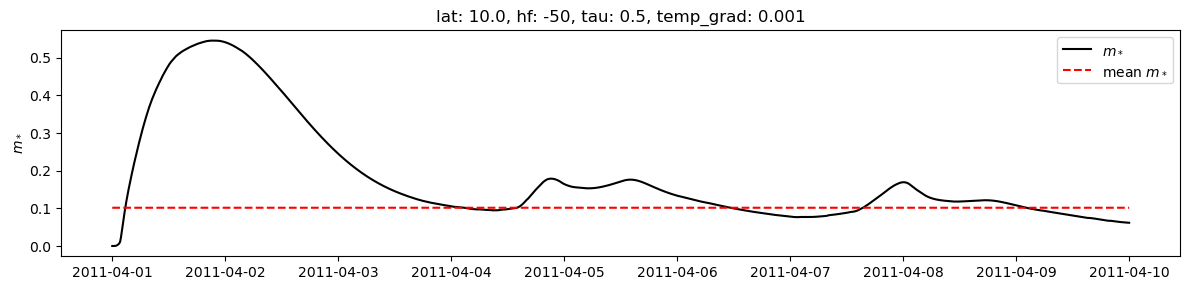

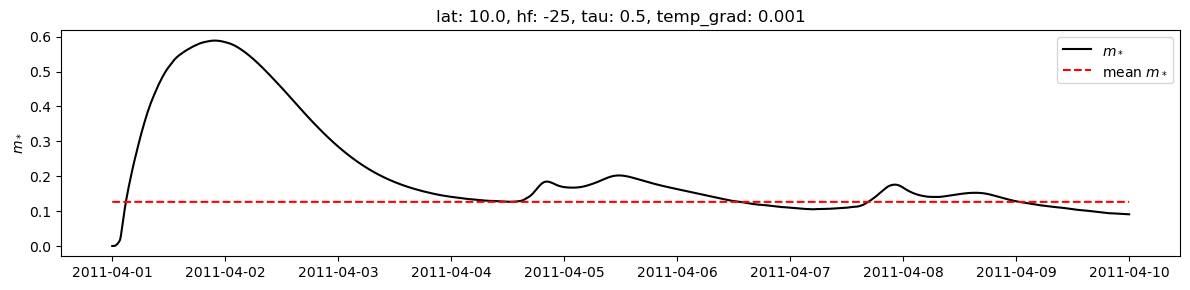

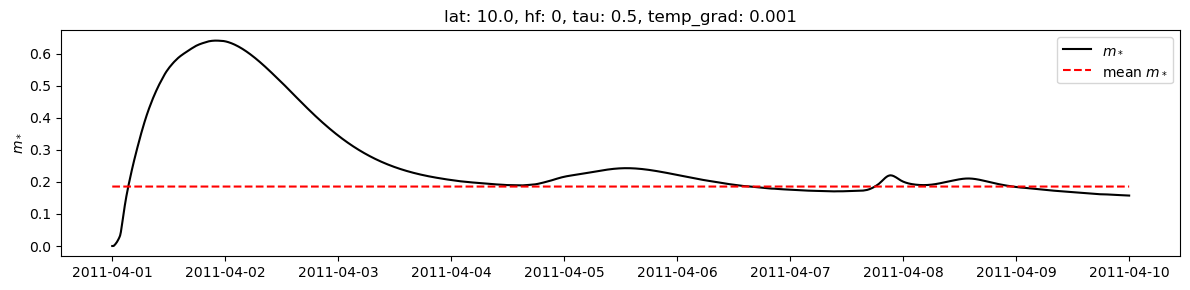

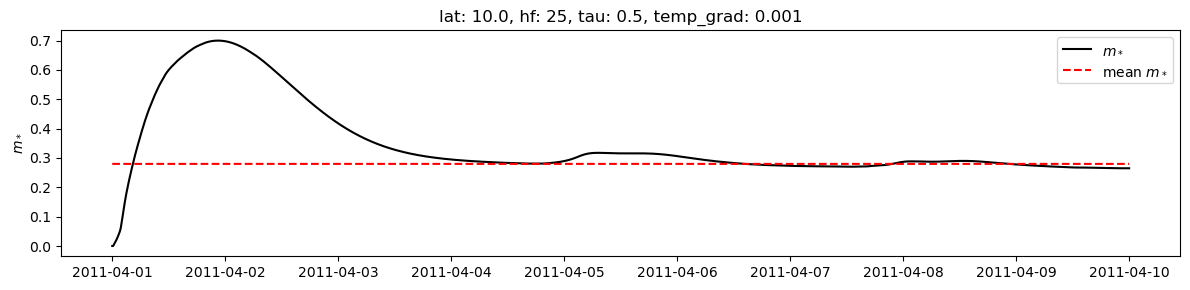

In [23]:
save = True

for i in range(1,60):
    plt.figure(figsize=(12,3))
    plt.plot(m_star_dataset.time.values, m_star_dataset.m_star.values[i,:], color="black",
             label="$m_*$")
    plt.plot(m_star_dataset.time.values, m_stars[i]*np.ones(len(m_star_dataset.m_star.values[i,:])), 
             color="red", linestyle="dashed", label="mean $m_*$")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/m_star_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}_hf_{hf}.png", dpi=300)

/tmp/ipykernel_4135791/2346346631.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


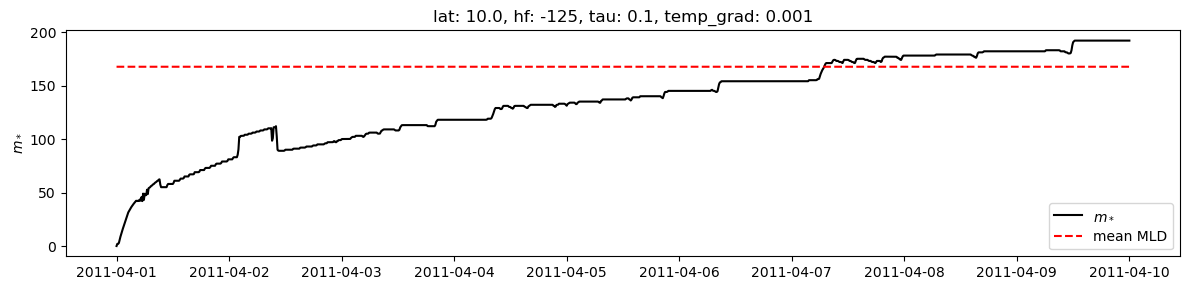

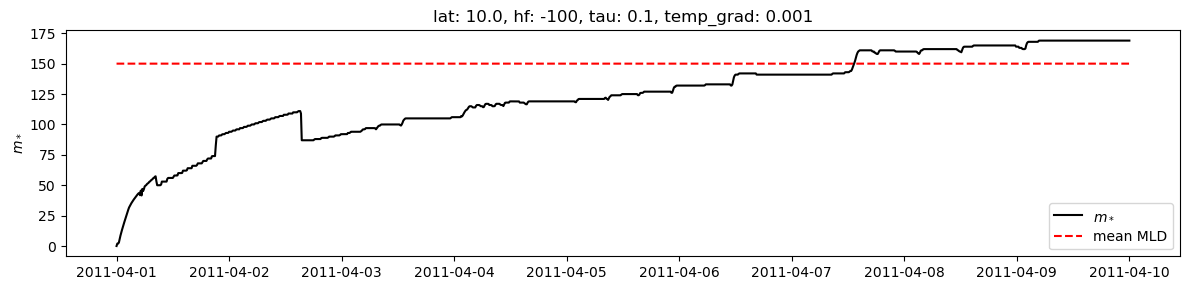

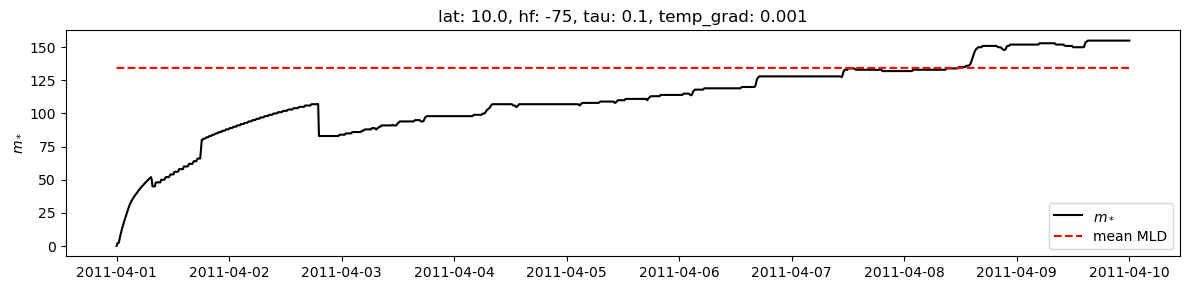

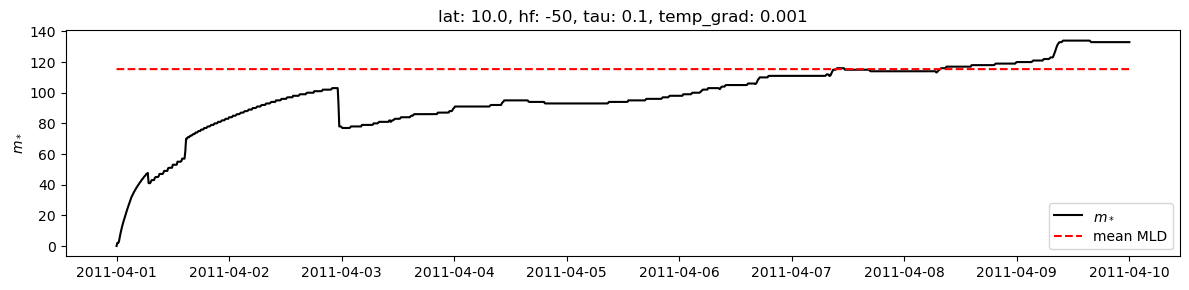

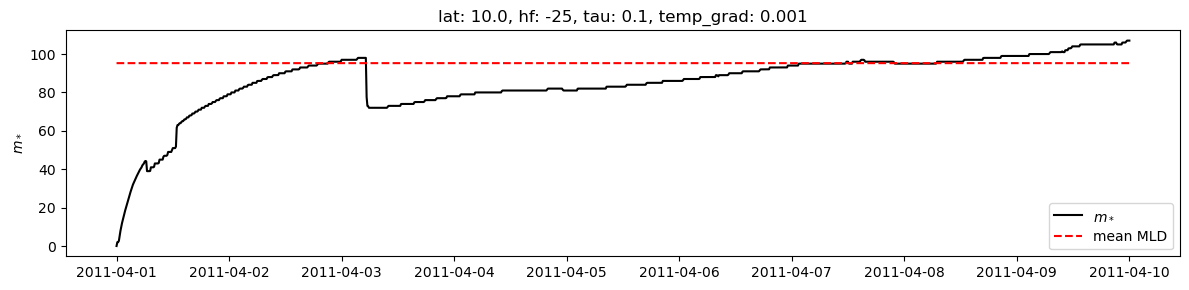

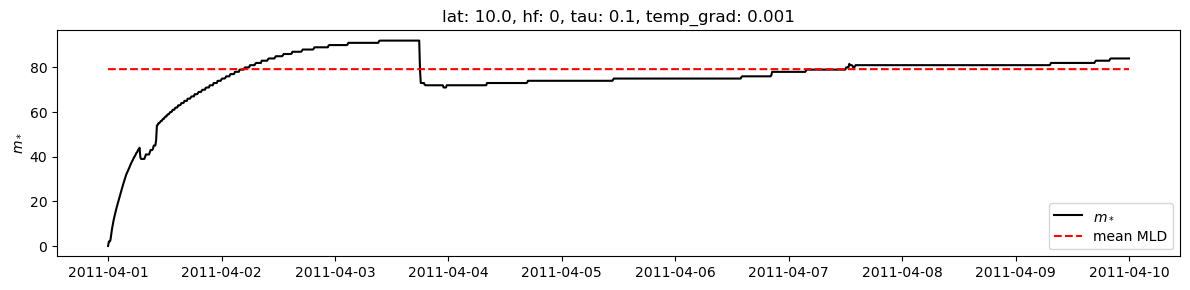

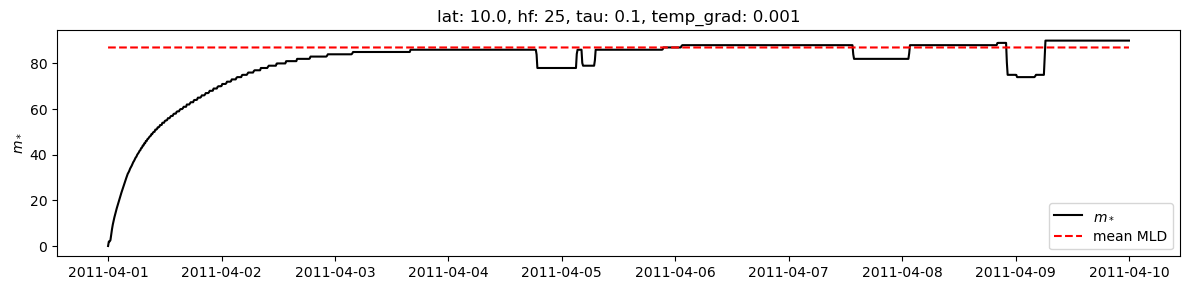

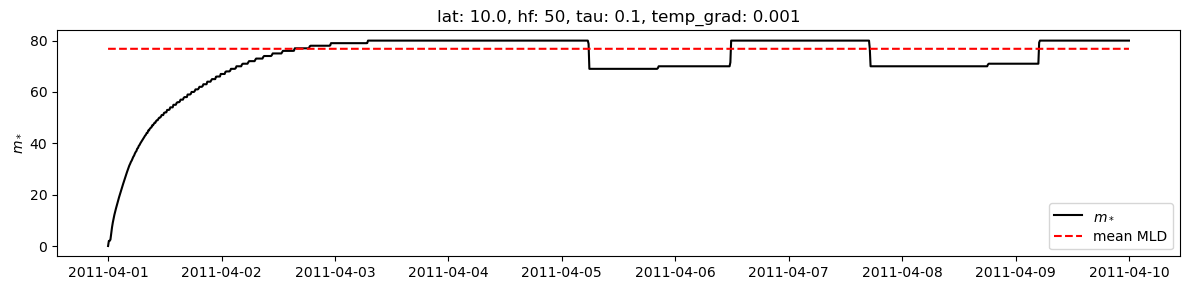

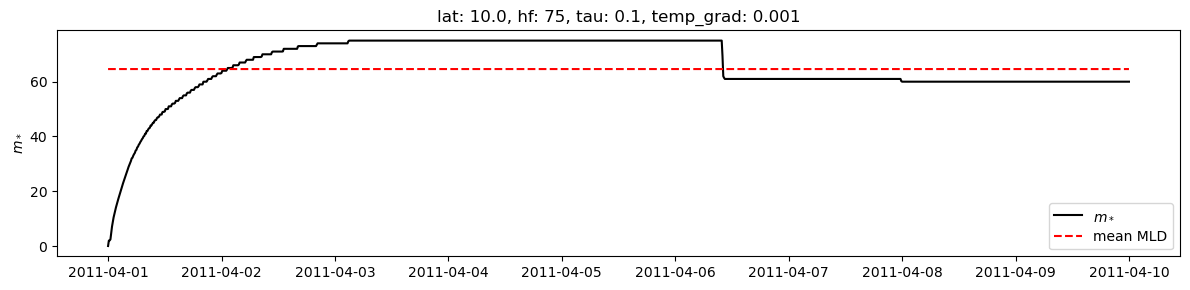

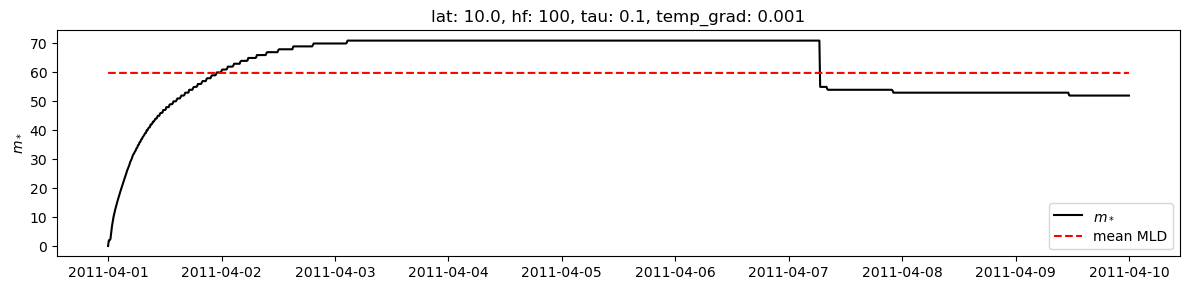

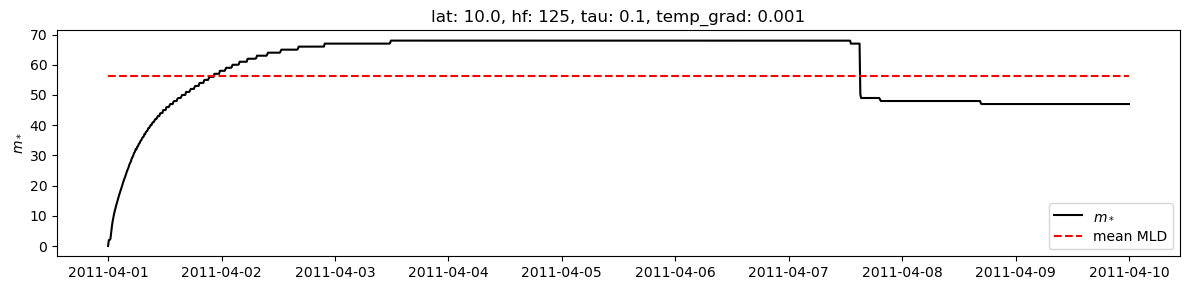

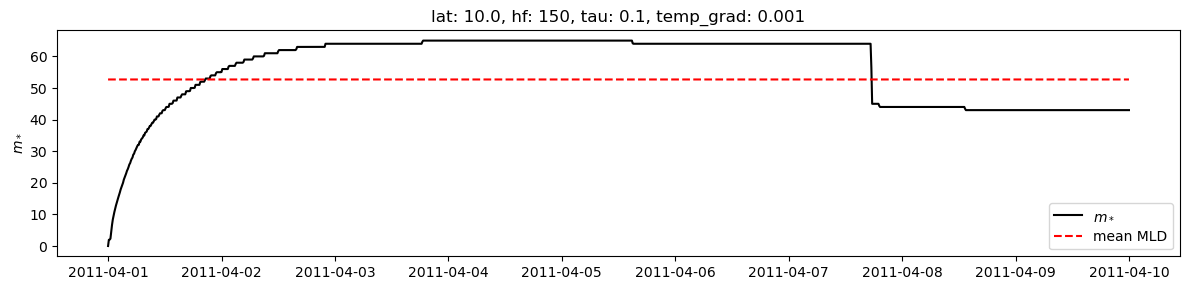

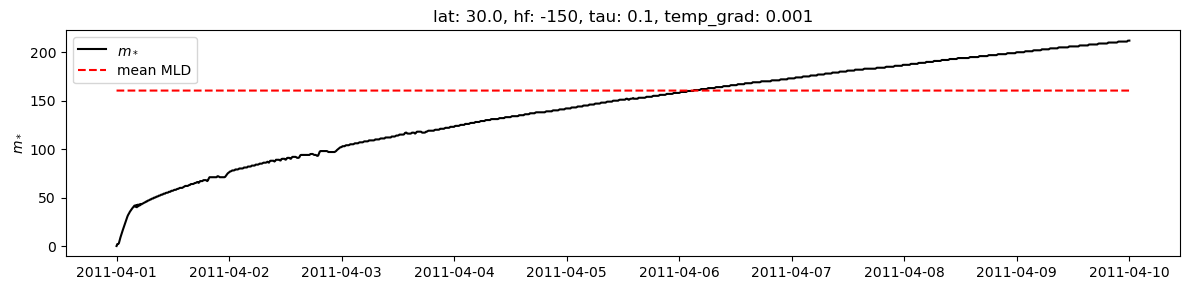

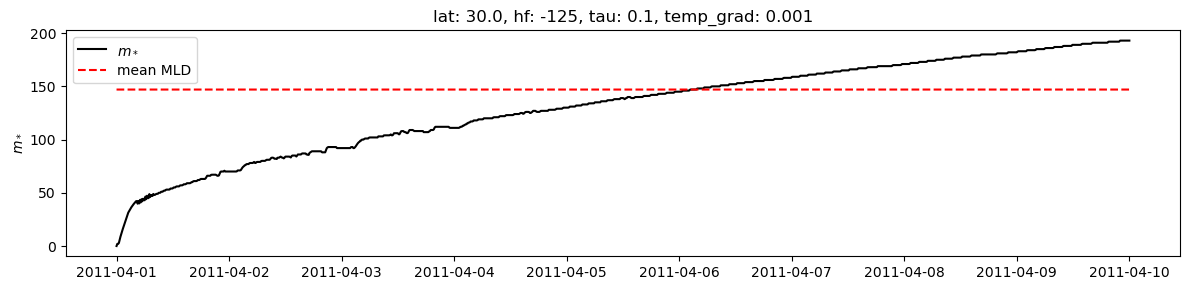

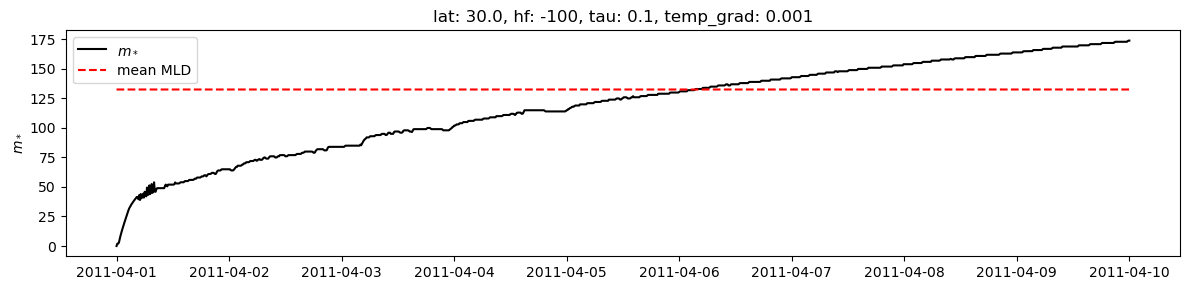

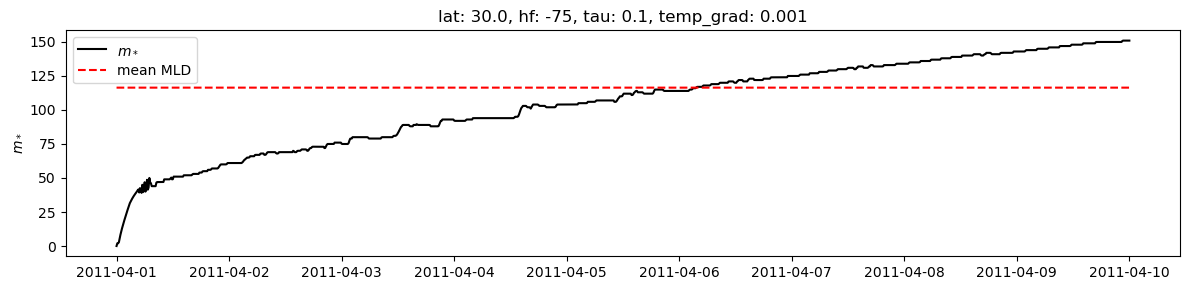

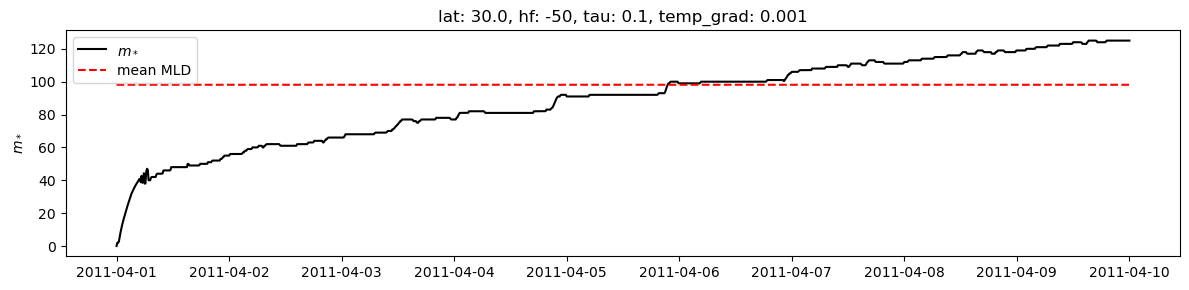

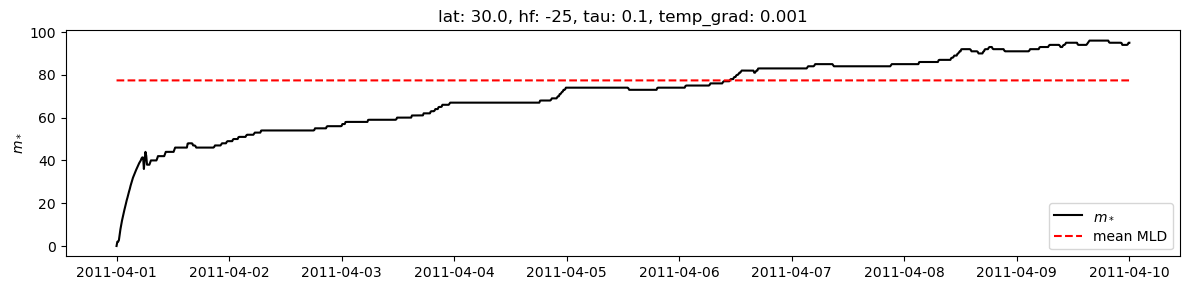

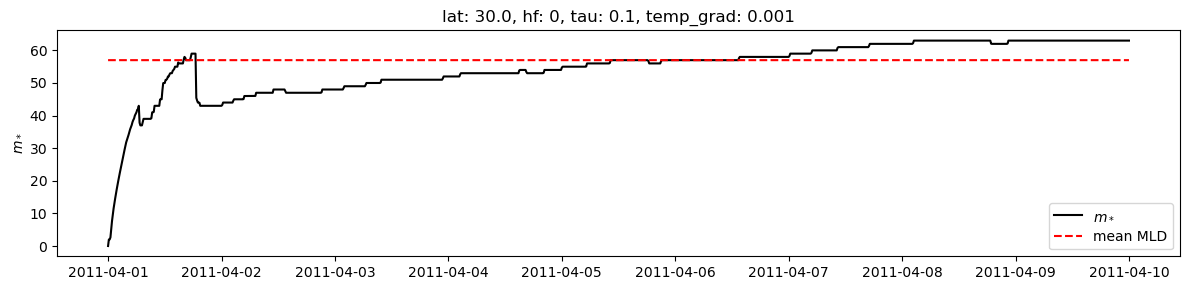

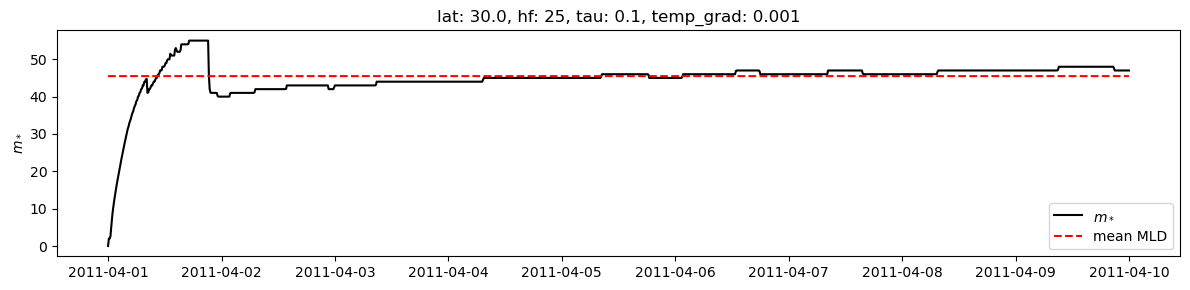

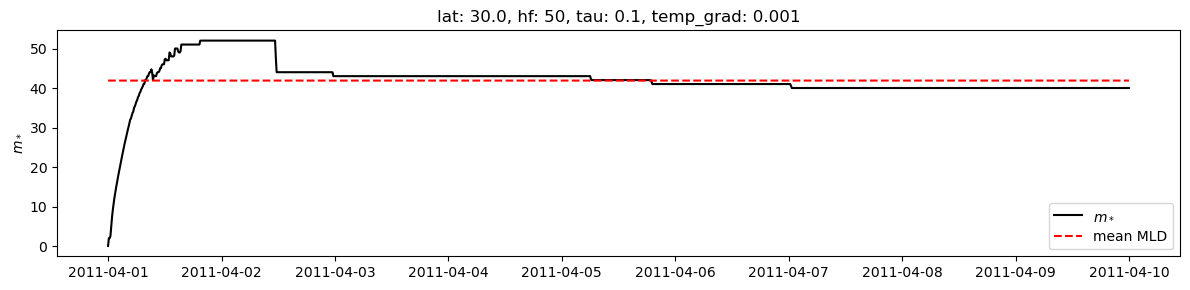

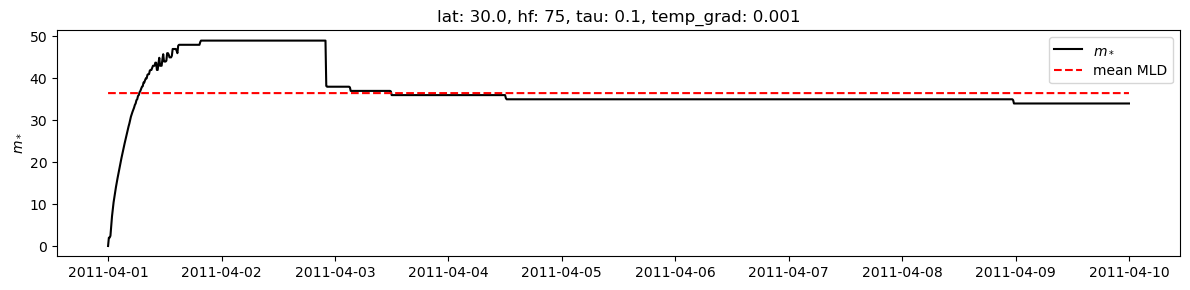

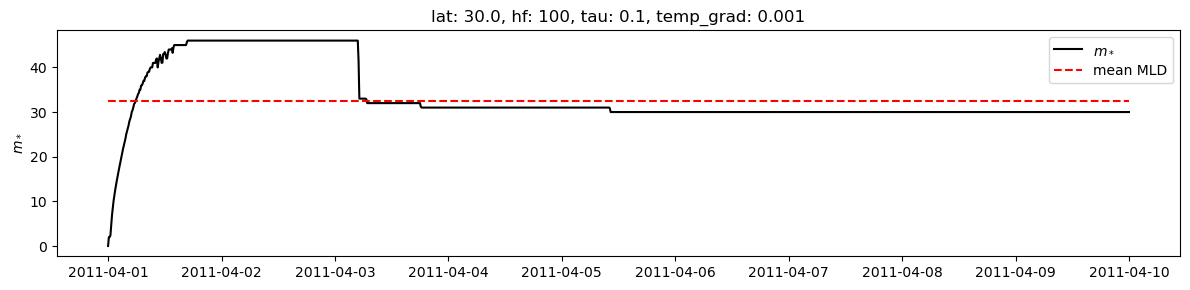

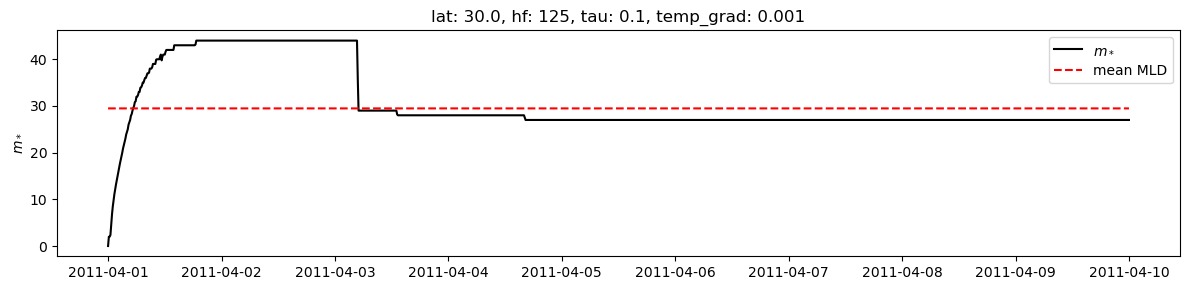

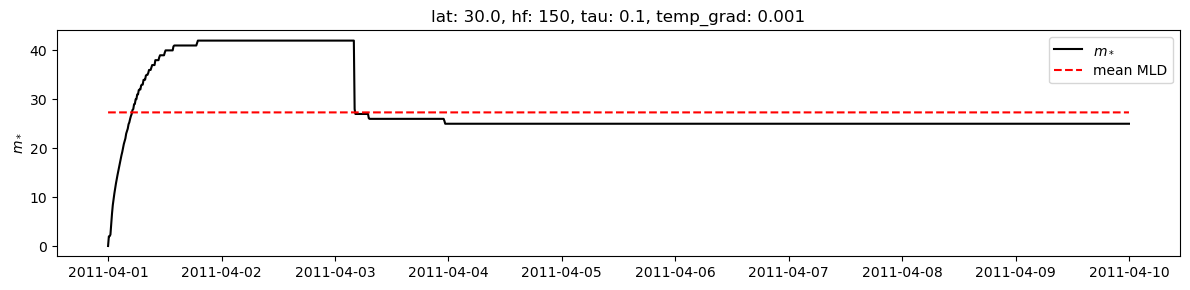

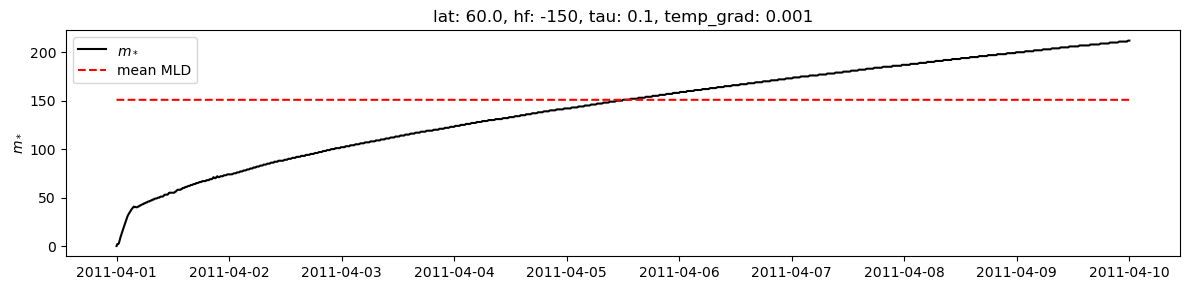

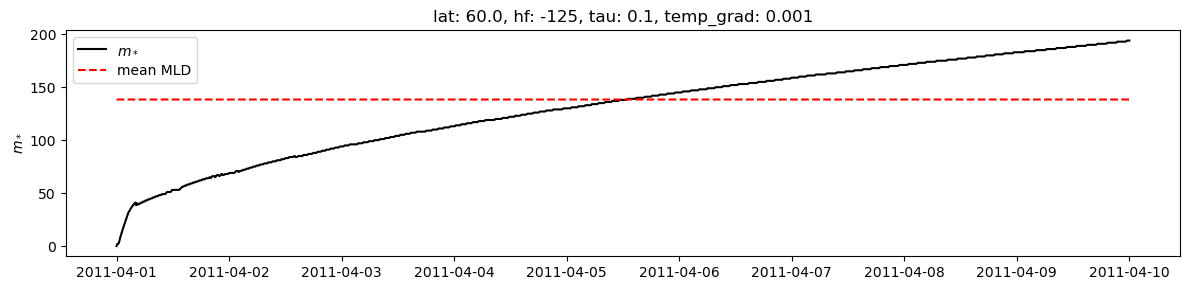

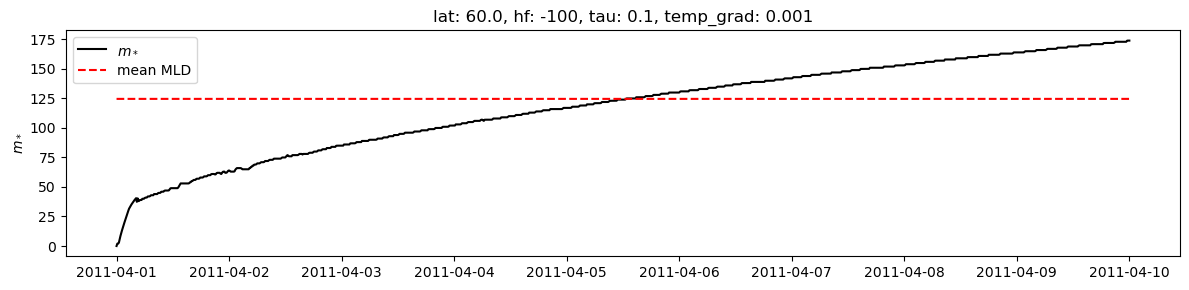

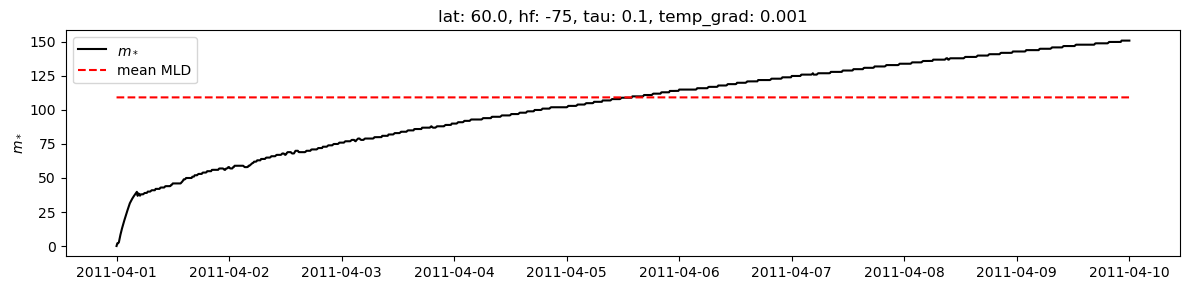

In [28]:
save = False

for i in range(1,30):
    plt.figure(figsize=(12,3))
    plt.plot(mld_dataset.time.values, mld_dataset.mld_surf.values[i,:], color="black",
             label="$m_*$")
    plt.plot(mld_dataset.time.values, mlds[i]*np.ones(len(mld_dataset.mld_surf.values[i,:])), 
             color="red", linestyle="dashed", label="mean MLD")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/mld_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}.png", dpi=300)

/tmp/ipykernel_4135791/2315494667.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,3))


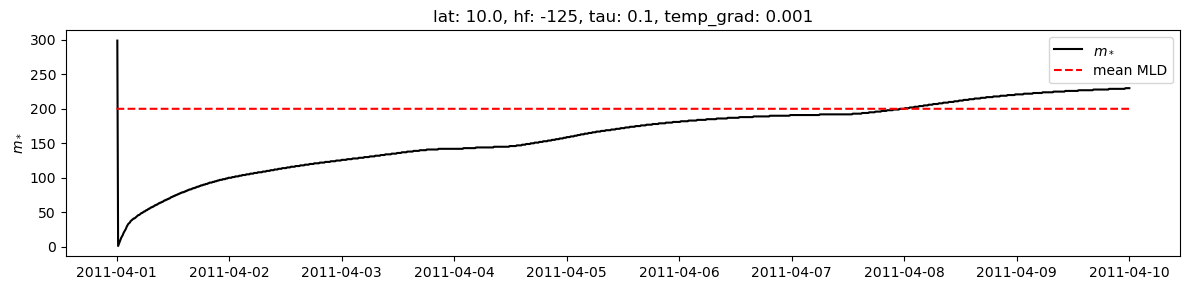

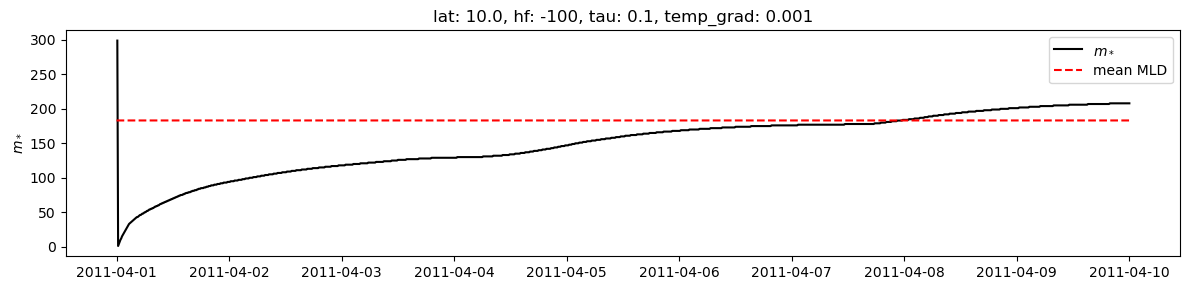

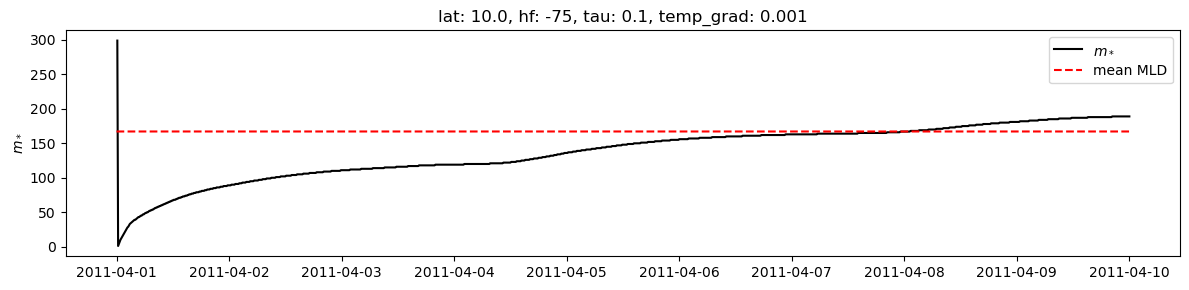

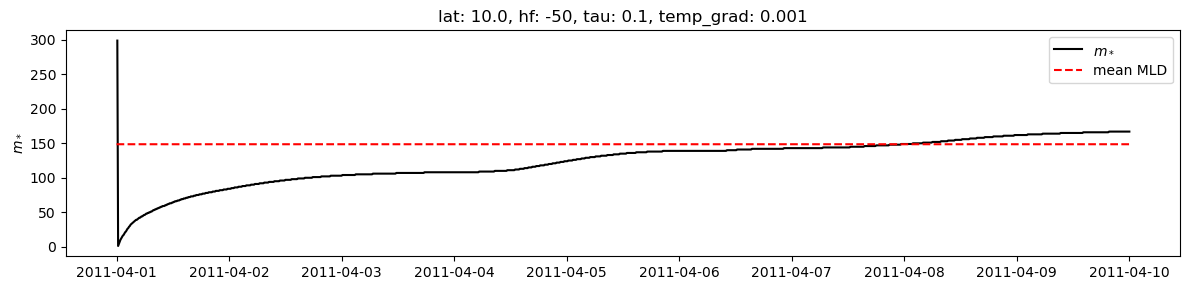

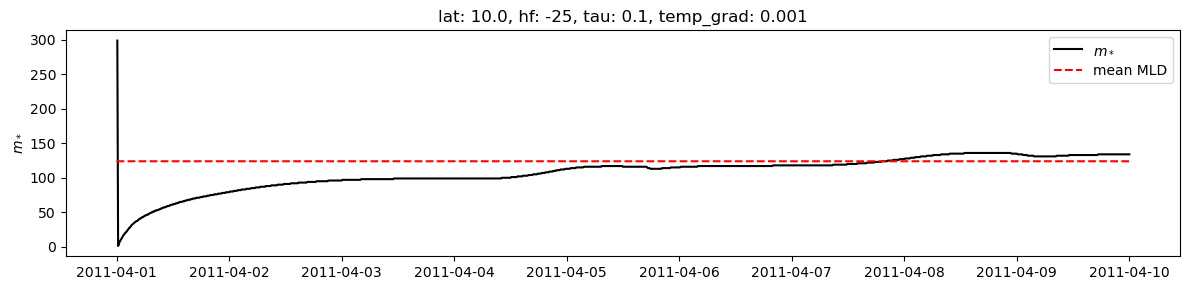

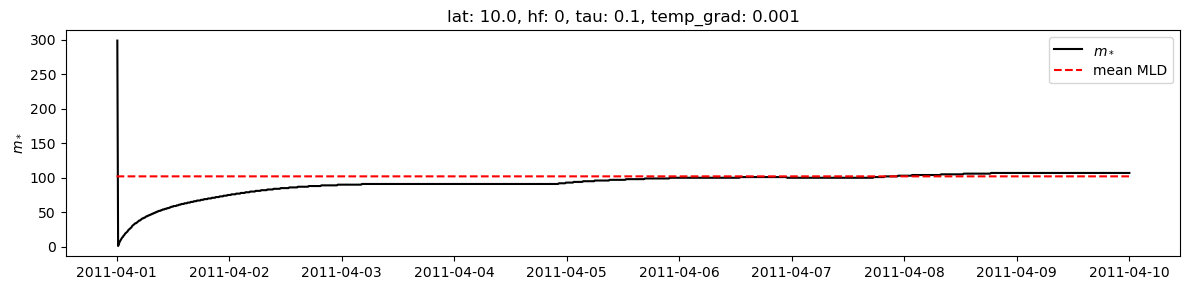

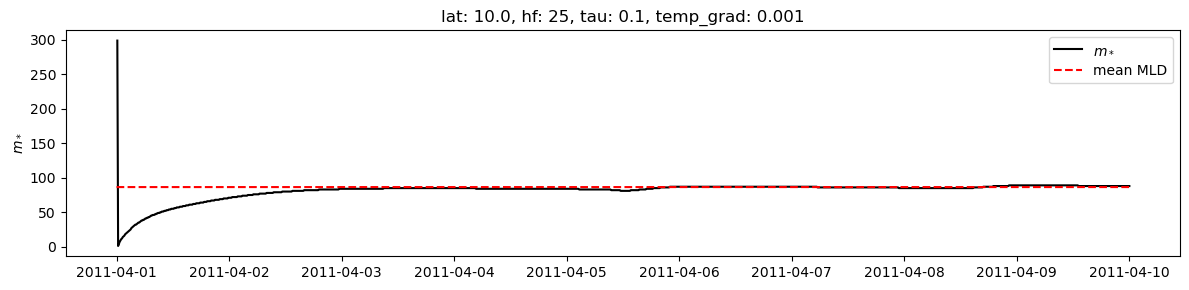

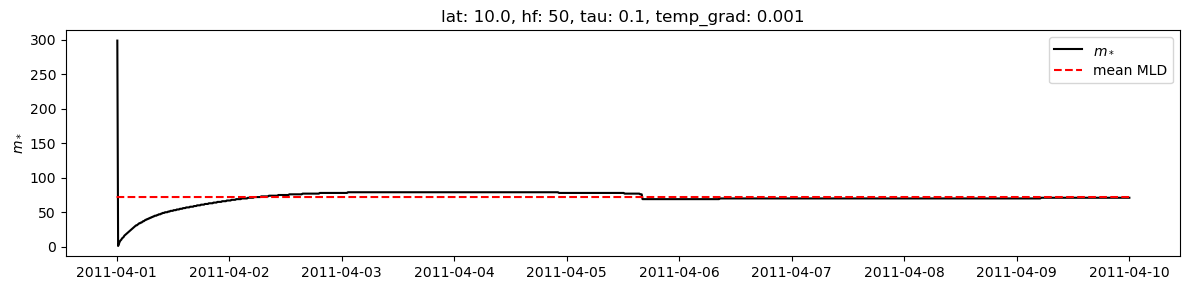

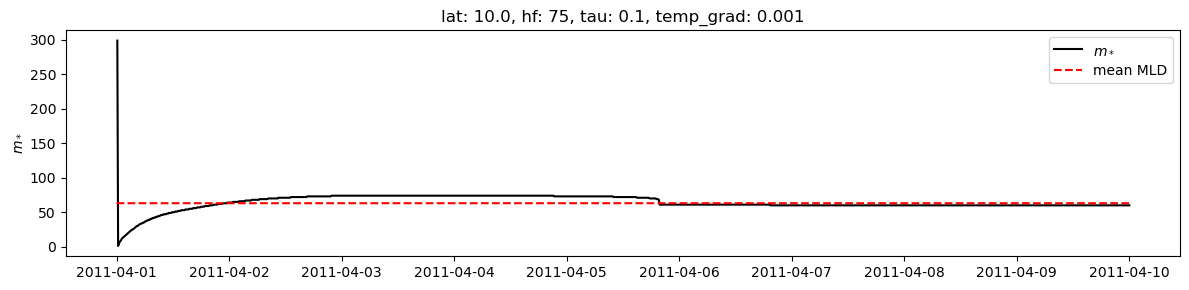

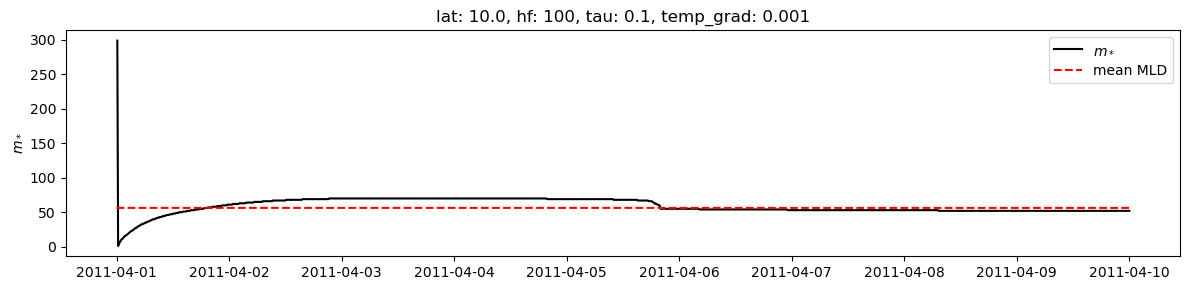

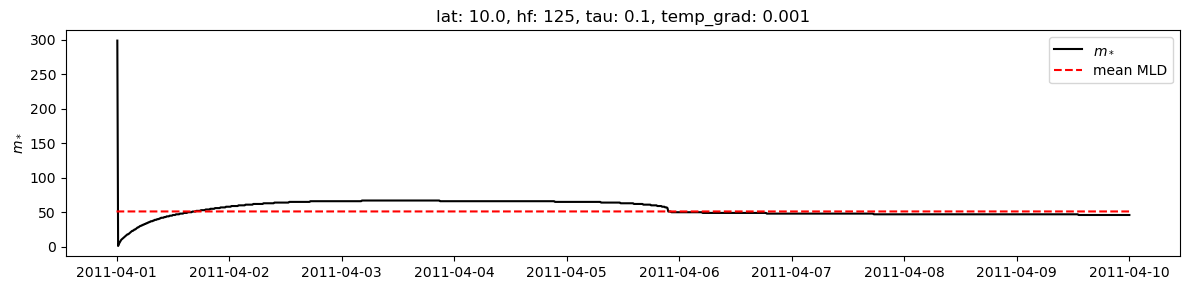

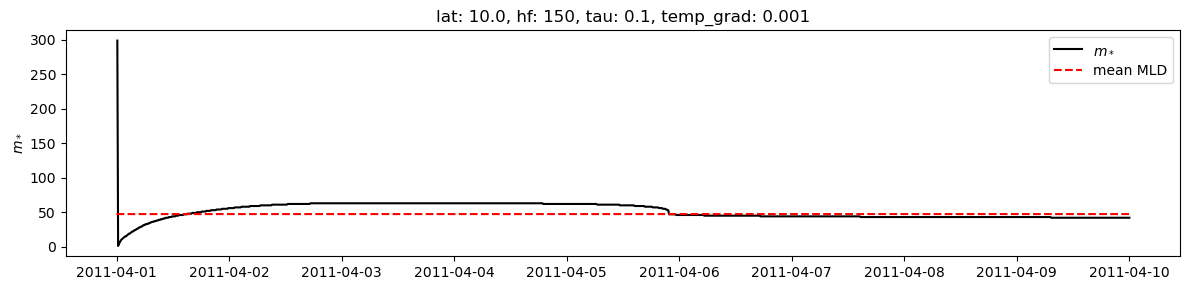

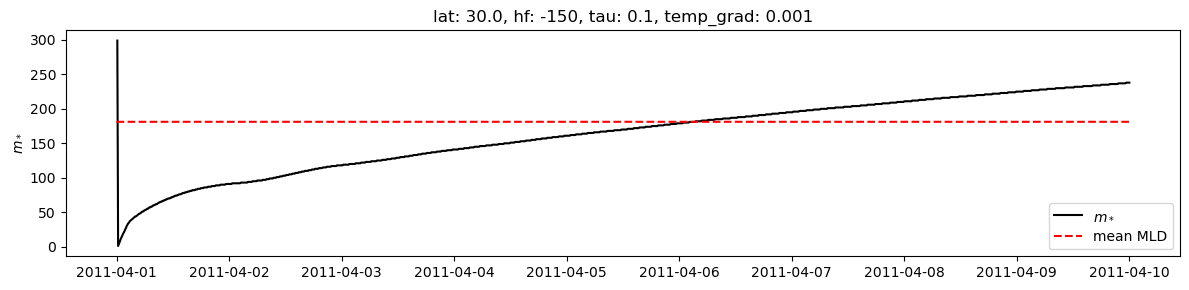

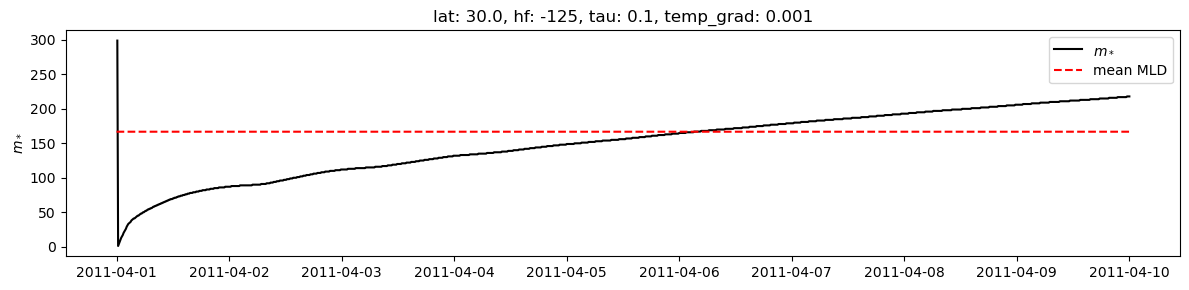

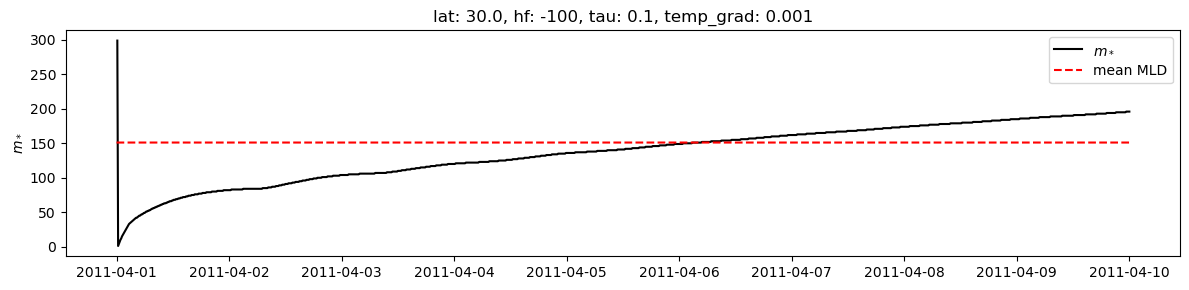

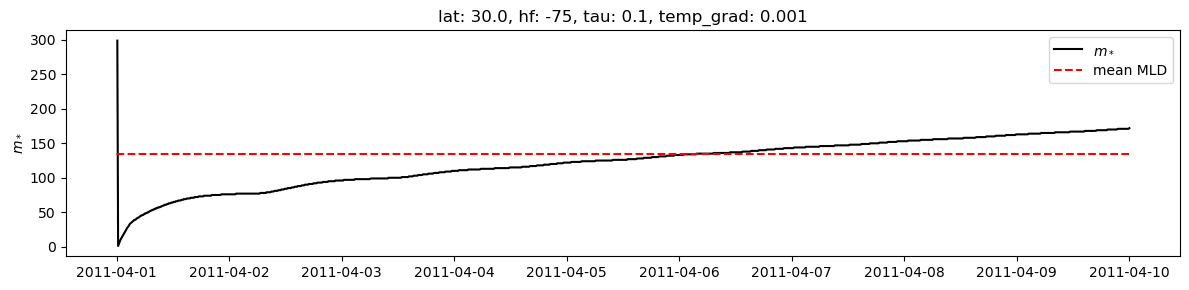

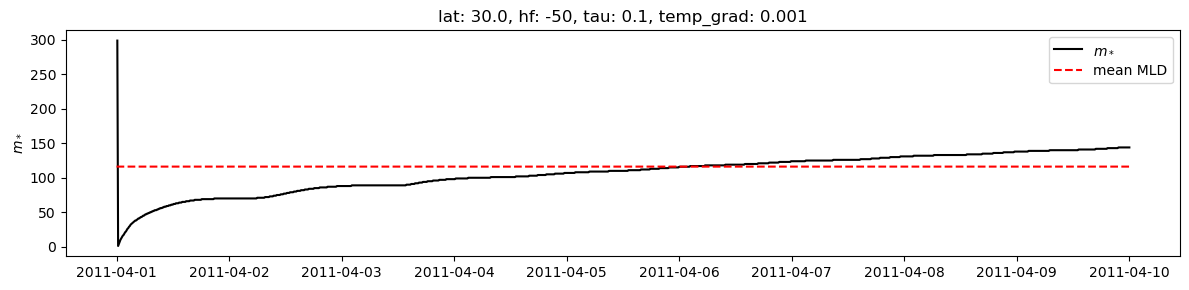

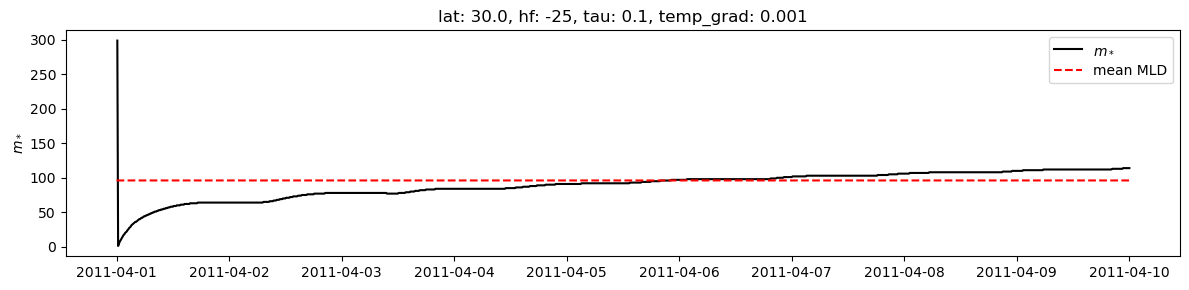

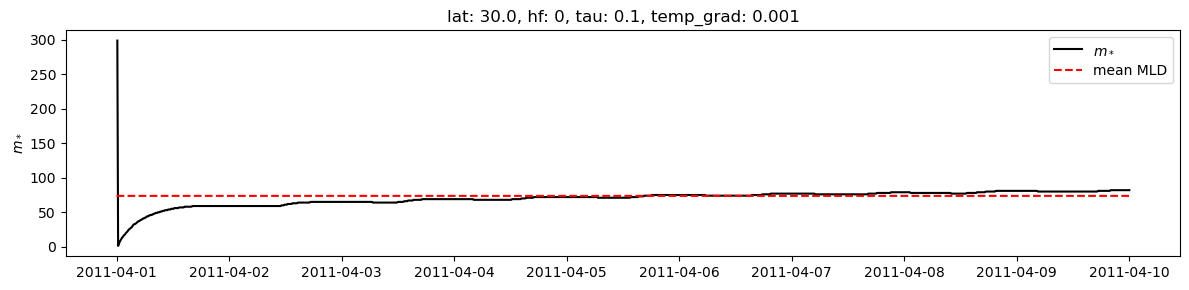

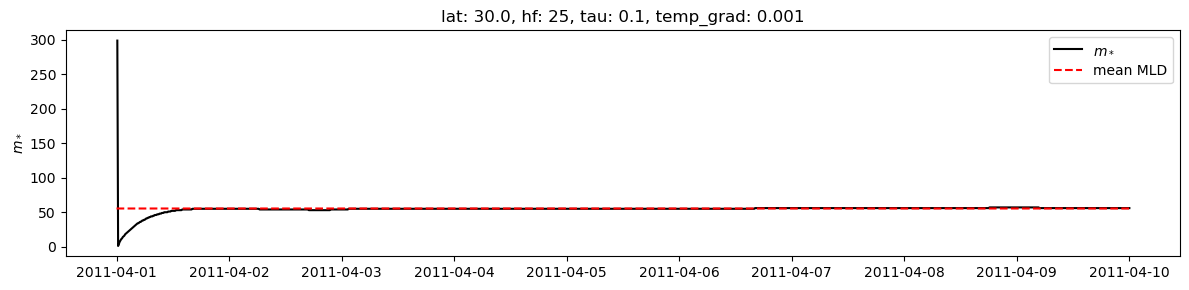

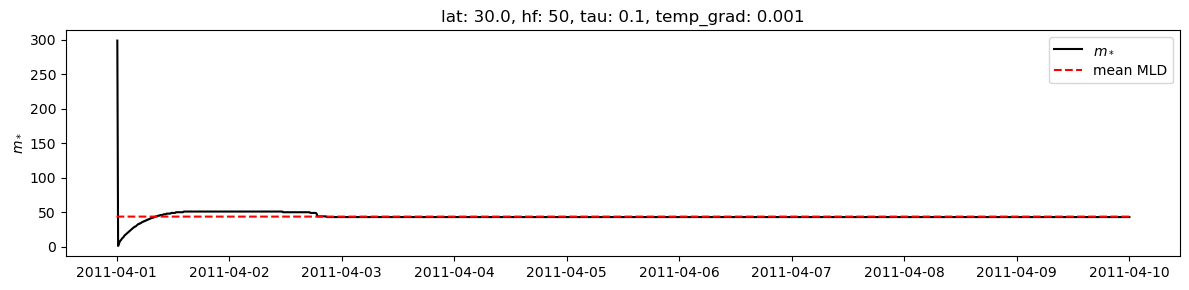

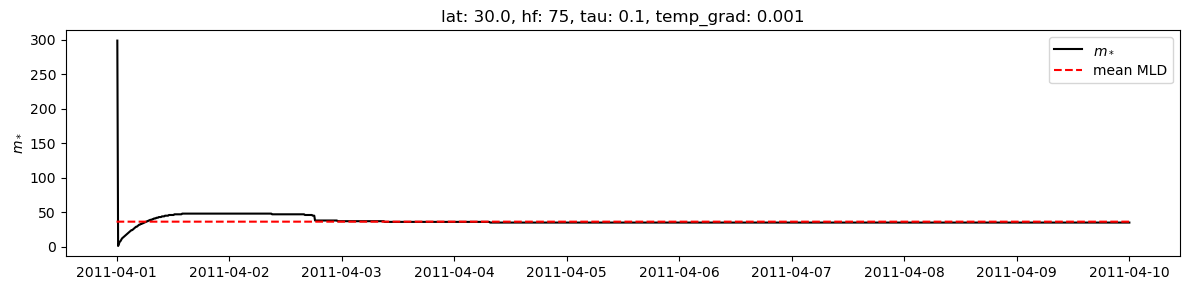

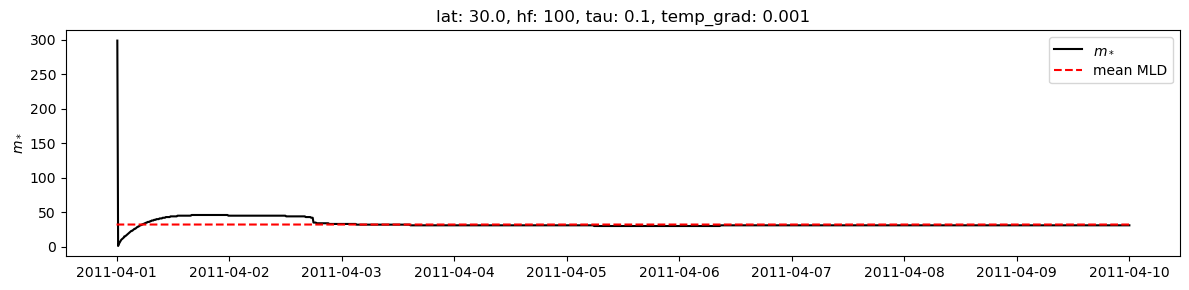

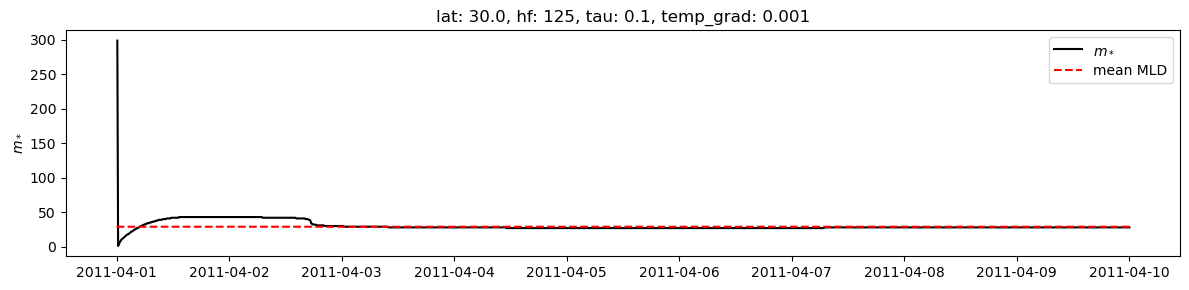

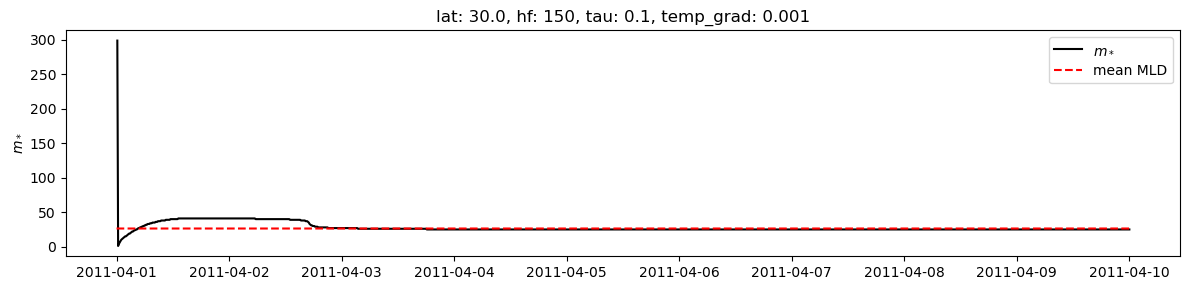

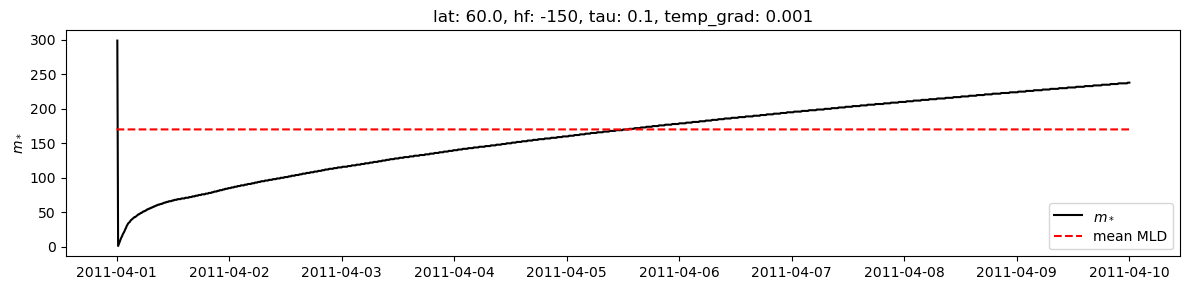

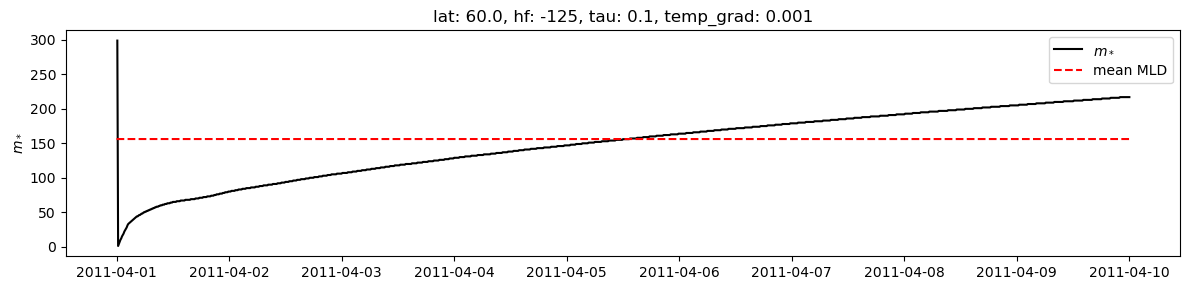

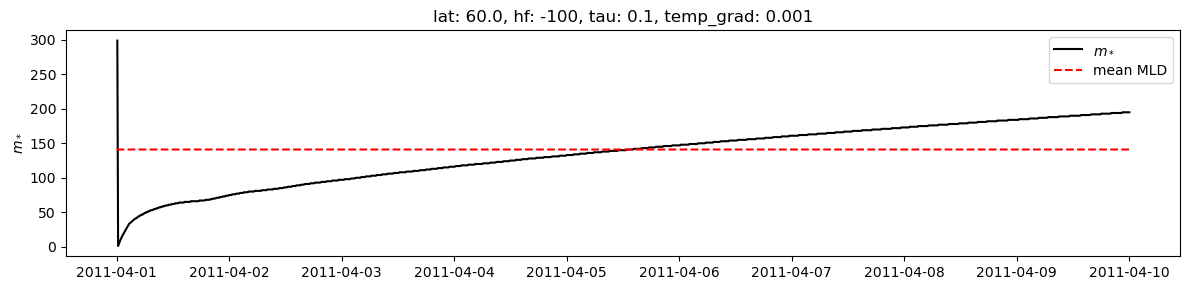

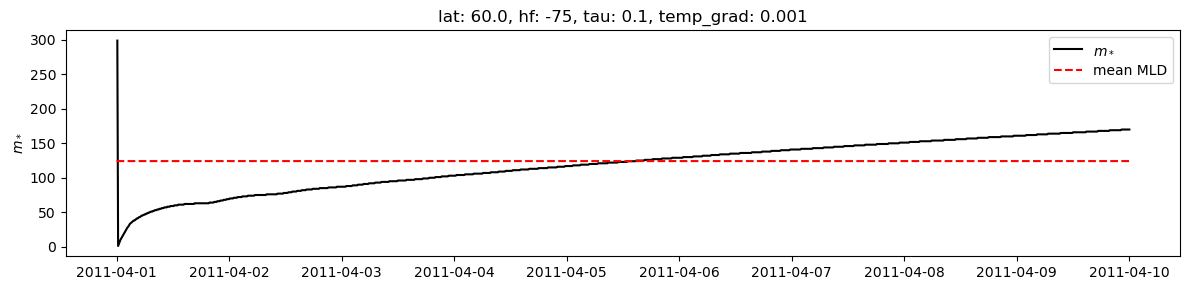

In [35]:
save = False

for i in range(1,30):
    plt.figure(figsize=(12,3))
    plt.plot(bl_dataset.time.values, bl_dataset.bl.values[i,:], color="black",
             label="$m_*$")
    plt.plot(bl_dataset.time.values, bls[i]*np.ones(len(bl_dataset.bl.values[i,:])), 
             color="red", linestyle="dashed", label="mean MLD")
    specs = gotm_case_dict[f'case_{i+1}']
    lat, hf, tau, tg = specs['lat'], specs['heat_flux'], specs['tx'], specs['temp_grad']
    plt.title(f"lat: {lat}, hf: {hf}, tau: {tau}, temp_grad: {tg}")
    plt.legend()
    plt.ylabel('$m_*$')
    plt.tight_layout()

    if save:
        plt.savefig(f"figures/{training_set_name}/mld_timeseries_{training_set_name}_lat_{lat}_tau_{tau}_tgrad_{tg}.png", dpi=300)

In [29]:
xs = np.array([bls[i]*calculate_f(case['lat']) / (case['tx'] / 1027) ** 0.5 for i, case in enumerate(gotm_case_dict.values())])

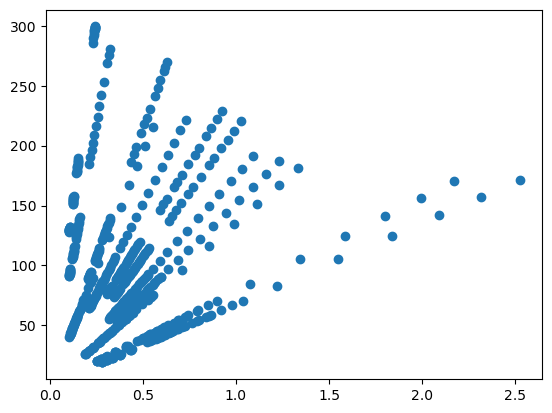

In [147]:
plt.scatter(xs, bls)

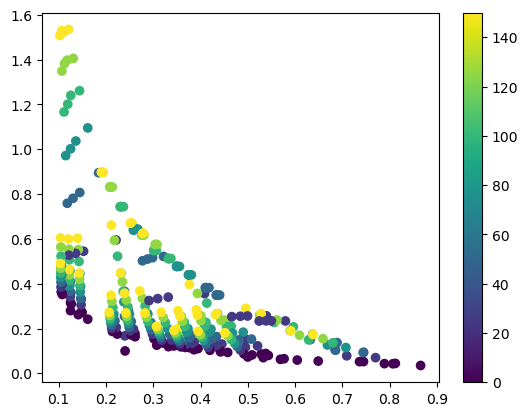

In [ ]:
plt.scatter(xs[heat_fluxes >=0], m_stars[heat_fluxes >=0], c=heat_fluxes[heat_fluxes>=0])
plt.colorbar()

Text(0.5, 0, '$|f|H_{bl}/u_*$')

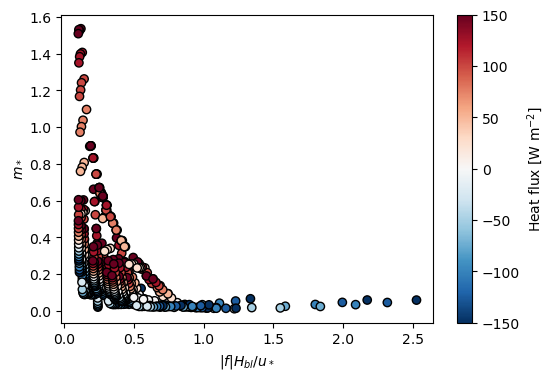

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(xs, m_stars, c=heat_fluxes, cmap="RdBu_r", edgecolors="black")
plt.colorbar(label="Heat flux [W m$^{-2}$]")
plt.ylabel("$m_*$")
plt.xlabel('$|f|H_{bl}/u_*$')

In [143]:
xs_no_hf = xs[heat_fluxes==0]
m_stars_no_hf = m_stars[heat_fluxes==0]
wind_stresses_no_hf = wind_stresses[heat_fluxes==0]

In [100]:
from scipy.optimize import curve_fit

In [122]:
param_N, param_cov_N = curve_fit(calculate_analytical_m_star_N, xs_no_hf[xs_no_hf>0.3], m_stars_no_hf[xs_no_hf>0.3], maxfev=10000)

In [123]:
param_Nb, param_cov_Nb = curve_fit(calculate_analytical_m_star_Nb, xs_no_hf, m_stars_no_hf, maxfev=10000)

In [124]:
print(param_Nb, param_N)

[0.46837869 3.71750517] [3.07531700e+02 9.50341811e-04 2.48267958e+00]


In [125]:
xs_N = np.linspace(0, 1, 1000)
m_star_N = calculate_analytical_m_star_N(xs_N, c_N1=0.275, c_N2 = 8.0, c_N3 = 5.0)
m_star_N_fitted = calculate_analytical_m_star_N(xs_N, c_N1=param_N[0], c_N2=param_N[1], c_N3=param_N[2])
m_star_Nb = calculate_analytical_m_star_Nb(xs_N, c_Nb1=0.5, c_Nb2=3.0)
m_star_Nb_fitted = calculate_analytical_m_star_Nb(xs_N, c_Nb1=param_Nb[0], c_Nb2=param_Nb[1])

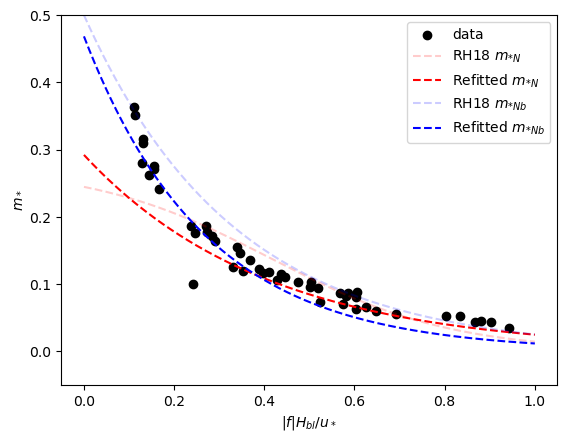

In [144]:
plt.scatter(xs_no_hf, m_stars_no_hf, color="black",
            label="data")
plt.plot(xs_N, m_star_N, color="red", linestyle="dashed", alpha=0.2, label="RH18 $m_{*N}$")
plt.plot(xs_N, m_star_N_fitted, color="red", linestyle="dashed", label="Refitted $m_{*N}$")
plt.plot(xs_N, m_star_Nb, color="blue", linestyle="dashed", alpha=0.2, label="RH18 $m_{*Nb}$")
plt.plot(xs_N, m_star_Nb_fitted, color="blue", linestyle="dashed", label="Refitted $m_{*Nb}$")

plt.ylabel('$m_*$')
plt.xlabel('$|f|H_{bl}/u_*$')
plt.ylim(-0.05, 0.5)

plt.legend()

# plt.savefig('analytical_m_star_corrected_G_and_BL.png', dpi=300)

In [88]:
criterion = np.logical_and(m_stars_no_hf<0.12, xs_no_hf<0.3)
m_stars_no_hf[criterion]

array([0.09989698])

In [91]:
cases_no_hf = cases[heat_fluxes == 0.]

In [92]:
cases_no_hf[criterion]

array([111])

In [93]:
gotm_case_dict["case_111"]

{'temp_grad': 0.001, 'tx': 1.0, 'lat': 10.0, 'heat_flux': 0}

In [28]:
xs_no_hf[xs_no_hf<0.18]

array([0.09684606, 0.07662154, 0.16397385, 0.07384873, 0.15360385,
       0.10362448, 0.08806268, 0.0847738 , 0.11664965, 0.10205737,
       0.10054444, 0.17481642, 0.17628083])

In [108]:
param_Nb

array([0.6014478 , 5.34636498])

In [109]:
param_N

array([3.07531700e+02, 9.50341811e-04, 2.48267958e+00])

In [51]:
m_stars[xs<0.15]

array([0.06860461, 0.07447092, 0.08590881, 0.11319754, 0.21270323,
       0.43341911, 0.63631921, 0.82285956, 0.98778909, 0.18945375,
       0.20480929, 0.22414484, 0.2488816 , 0.28200098, 0.31970406,
       0.3567113 , 0.39342481, 0.42954914, 0.24140859, 0.25278279,
       0.26597925, 0.28112565, 0.29838061, 0.31666654, 0.33516032,
       0.3530647 , 0.37124732, 0.06109941, 0.06533392, 0.07752787,
       0.10138289, 0.20095752, 0.44173056, 0.65641548, 0.84924468,
       1.01249501, 0.15280928, 0.16718627, 0.18549925, 0.21094185,
       0.24770003, 0.29112843, 0.33404653, 0.37574992, 0.41676496,
       0.19568515, 0.20744671, 0.22120212, 0.23755013, 0.257522  ,
       0.27892969, 0.30051888, 0.32149094, 0.34227587, 0.061648  ,
       0.07050712, 0.08928131, 0.18727698, 0.45141159, 0.67855344,
       0.8764068 , 1.03147922, 0.12363695, 0.13615493, 0.15337187,
       0.17859463, 0.21894319, 0.26938133, 0.31856684, 0.36599047,
       0.41257152, 0.15906052, 0.17089423, 0.18493982, 0.20229

In [50]:
calculate_analytical_m_star_Nb(xs[xs<0.15], c_Nb1=0.67004016, c_Nb2=11.22563986)

array([0.1978814 , 0.20823314, 0.21900761, 0.22935463, 0.22591949,
       0.1982848 , 0.18148905, 0.18908242, 0.198926  , 0.28168806,
       0.28159825, 0.28283389, 0.28367301, 0.28349993, 0.28285014,
       0.2828731 , 0.2829648 , 0.2821083 , 0.29309523, 0.29235464,
       0.29236231, 0.29334649, 0.29246308, 0.2929078 , 0.29341546,
       0.29363301, 0.29361269, 0.15541029, 0.16918113, 0.18385709,
       0.1991042 , 0.20936655, 0.17754232, 0.16112233, 0.17029808,
       0.18374662, 0.24001149, 0.24361203, 0.24614813, 0.24782425,
       0.24933009, 0.24957962, 0.25028222, 0.25014829, 0.25074973,
       0.25152933, 0.25344281, 0.25540036, 0.25666622, 0.25870736,
       0.25885299, 0.26097469, 0.26080386, 0.26094281, 0.12477358,
       0.14483808, 0.16417311, 0.18088667, 0.15452791, 0.14059775,
       0.15507558, 0.17945629, 0.1952318 , 0.20013113, 0.20443179,
       0.20891892, 0.21308228, 0.21613317, 0.21790343, 0.21950382,
       0.22019439, 0.20784629, 0.21057653, 0.21248409, 0.21459

In [54]:
np.sqrt(np.mean((calculate_analytical_m_star_N(xs_no_hf[xs_no_hf>0.15], c_N1=5.71097692e+02, c_N2=4.91134967e-04, c_N3=4.31117990e+00) - m_stars_no_hf[xs_no_hf>0.15]) ** 2))

np.float64(0.007059211505307918)

In [55]:
np.sqrt(np.mean((calculate_analytical_m_star_Nb(xs_no_hf[xs_no_hf<0.15], c_Nb1=0.67004016, c_Nb2=11.22563986) - m_stars_no_hf[xs_no_hf<0.15]) ** 2))

np.float64(0.006888117279246969)

Text(0, 0.5, 'm_star')

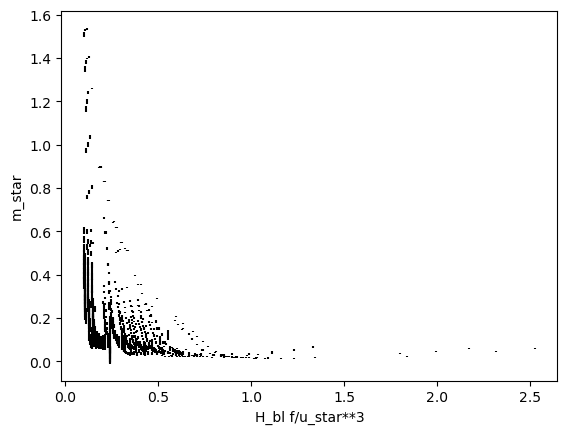

In [37]:
plt.figure()
plt.errorbar(xs, m_stars, yerr=np.sqrt(m_star_variances), color="black", linestyle="None")
plt.xlabel('H_bl f/u_star**3')
plt.ylabel('m_star')

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4014720/1138601053.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_{m_*}/m_*$')


(-0.5, 3.0)

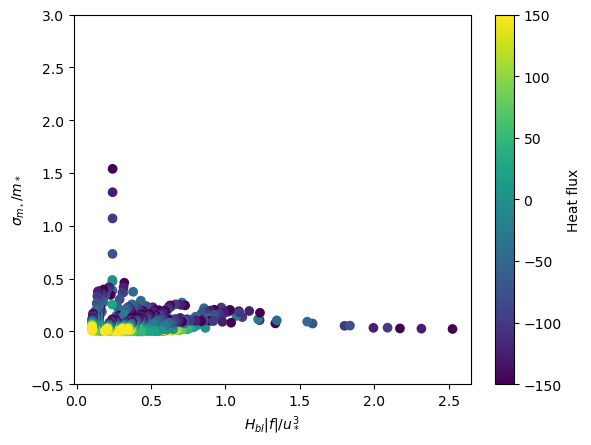

In [38]:
plt.scatter(xs, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)
plt.colorbar(label='Heat flux')
plt.ylabel('$\sigma_{m_*}/m_*$')
plt.xlabel('$H_{bl} |f|/u_*^3$')
plt.ylim(-0.5,3)
# plt.savefig('m_star_vs_m_star_variances.png', dpi=300)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3796103/1128819296.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_{m_*}/m_*$')
/tmp/ipykernel_3796103/1128819296.py:1: RuntimeWarning: invalid value encountered in divide
  plt.scatter(m_stars, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)


(-0.5, 3.0)

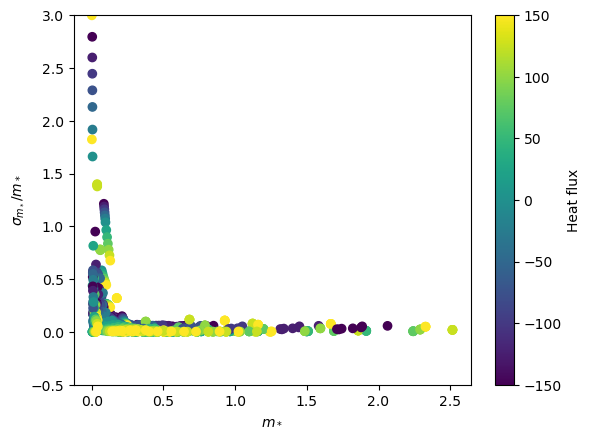

In [144]:
plt.scatter(m_stars, np.sqrt(m_star_variances)/m_stars, c=heat_fluxes)
plt.colorbar(label='Heat flux')
plt.ylabel('$\sigma_{m_*}/m_*$')
plt.xlabel('$m_*$')
plt.ylim(-0.5,3)
# plt.savefig('m_star_vs_m_star_variances.png', dpi=300)